# Homework 03: Learning Curves and Training Workflow

**Points:** 85

In this assignment, you will learn how to design, train, and evaluate neural networks by systematically exploring key design choices. Your focus will be on developing an effective **training workflow** — using learning curves and validation metrics to guide your decisions.

We'll use the **Forest Cover Type (Covertype) dataset,** which has ~581k tabular records with 54 cartographic/topographic features (elevation, aspect, slope, soil and wilderness indicators) used to predict one of seven tree cover types in Colorado’s Roosevelt National Forest. It’s a large, mildly imbalanced multi-class benchmark commonly used to compare classical ML and deep learning on tabular data.

We will start with a **baseline model** (two hidden layers of sizes 64 and 32), and gradually introduce and tune different hyperparameters. Each of the first five problems considers  different hyperparameter choices, and the last problem is your chance to use what you have learned to design your best model:

1. **Activation function** – Compare ReLU, sigmoid, and tanh to see which provides the best accuracy.
2. **Learning rate** – Explore a range of learning rates and identify which balances convergence speed and stability.
3. **Dropout** – Investigate how different dropout rates reduce overfitting and where they are most effective.
4. **L2 regularization** – Experiment with weight penalties to encourage simpler models and avoid memorization.
5. **Dropout + L2** – Combine both regularization techniques and study their interaction.
6. **Best model design** – Use all your insights to build and train your strongest model, with the option to try **learning rate scheduling** for further improvement.

In this homework, you will use **early stopping** to select the "best" model at the epoch of **minimum validation loss**, and you will report the **validation accuracy** of that selected model as the primary measure of performance. Test accuracy is reported for reference but is not used for model selection.

> **Note:** Throughout this homework, best always refers to the model selected by early stopping at the epoch of minimum validation loss. Do not report metrics from the final training epoch unless explicitly instructed.

By the end of this homework, you will not only understand how different hyperparameters affect training and generalization, but also gain hands-on practice in building a disciplined workflow for model development.

There are 10 graded problems, worth 8 points each, with 5 points for free if you complete the homework. 

In [1]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# utility code

random_seed = 42

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


In [2]:
# Utility function to plot learning curves and keep track of all results

# Call `print_results()` to see listing of all results logged so far


def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(1,2, figsize=(16, 6), sharex=True)# changed to have loss and accuracy plots side by side 

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')

    axs[0].annotate(
    f'{min_val_loss:.4f}',
    xy=(min_val_epoch + 1, min_val_loss),
    xytext=(min_val_epoch + 1, min_val_loss + 0.02),
    textcoords='data',
    fontsize=9,
    color='red',
    arrowprops=dict(arrowstyle='->', color='red')
    )

    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss',fontsize=12)
    axs[0].set_xlabel('Epoch', fontsize=10)
    axs[0].set_ylabel('Loss', fontsize=10)
    axs[0].legend(fontsize=9)
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].annotate(
    f'{val_acc_at_min_loss:.4f}',
    xy=(min_val_epoch + 1, val_acc_at_min_loss),
    xytext=(min_val_epoch + 1, val_acc_at_min_loss - 0.08),
    fontsize=9,
    color='red',
    arrowprops=dict(arrowstyle='->', color='red')
    )

    axs[1].set_title(f'{title} - Accuracy',fontsize=12)
    axs[1].set_xlabel('Epoch', fontsize=10)
    axs[1].set_ylabel('Accuracy', fontsize=10)
    axs[1].legend(fontsize=9)
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.subplots_adjust(wspace=0.3)  # space between the two plots
    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

**The plotting function will record the validation accuracy for each experiment, using the plot title as key. The next function will print these out (see the last cell in the notebook).**


In order to see all results, you must give a different plot title to each experiment.

In [3]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

### Wrapper to train, display results, and run test set

We assume multi-class classification, and allow setting various parameters for training. 

In [4]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model, 
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer=opt, 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )
    

    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]
    
    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the dataset and extract a stratified subset

This data set is rather large (581,012 samples) and unbalanced, but for the purposes of this homework, we use a much smaller set, and select samples so that it is balanced. 

In [5]:
# complete cell: load, balance, split into X_train/y_train/x_val/y_val/X_test/y_test, and standardize
from collections import Counter
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1) load
x, y = fetch_covtype(return_X_y=True)  # y in {1..7}
print("full dataset shape:", x.shape)

# 2) build a perfectly balanced subset across 7 classes (no replacement)
classes, counts = np.unique(y, return_counts=True)
# min_count = counts.min()  # size of rarest class                         # You can modify this parameter to increase the size of the dataset, but above
min_count = 1000                                                           # counts.min() you'll produce an unbalanced set. 


rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

# 3) stratified 60/20/20 split (train/val/test)
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

# 4) standardize using train-only stats (float32 for tensorflow friendliness)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# 5) quick sanity checks
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)

# you now have: X_train, y_train, X_val, y_val, X_test, y_test

# Looks like integer encoded multi-class, let's check and define the global n_classes

labels = np.unique(y_train)

n_classes = len(labels)

print("class labels:",labels)


full dataset shape: (581012, 54)
balanced subset shape: (7000, 54) class counts: {np.int32(2): 1000, np.int32(0): 1000, np.int32(4): 1000, np.int32(5): 1000, np.int32(1): 1000, np.int32(3): 1000, np.int32(6): 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={np.int32(2): 600, np.int32(1): 600, np.int32(0): 600, np.int32(3): 600, np.int32(5): 600, np.int32(4): 600, np.int32(6): 600}
val  : total=1400, per-class={np.int32(1): 200, np.int32(6): 200, np.int32(5): 200, np.int32(4): 200, np.int32(3): 200, np.int32(2): 200, np.int32(0): 200}
test : total=1400, per-class={np.int32(0): 200, np.int32(6): 200, np.int32(2): 200, np.int32(3): 200, np.int32(4): 200, np.int32(5): 200, np.int32(1): 200}
class labels: [0 1 2 3 4 5 6]


## Prelude: Defining a model builder

In order to facilitate our experimentation, we'll write a function which builds models according to specifications:

- How many layers
- How wide each layer is
- How much dropout in each layer
- How much L2 Regularization in each layer

This is a fairly standard practice in ML, since the structure of simple models is fairly predictable and can be specified by a few hyperparameters. 

In [6]:
# This function will build a multi-class classifier with dropout and L2 regularization.
# You must specify the number of input features, the number of classes, and a list of layer hyperparameters
# in the form  [ ...., (width, activation function, L2 lambda, dropout rate), .... ]

# Note that when adding dropout, this appears as a separate layer, but it has no parameters to be trained. 

def build_model(n_inputs,layer_list,n_classes):
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, activation=act, kernel_regularizer=regularizers.l2(l2_lambda)) )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )


**Example: To build the following model:**

In [7]:
model = models.Sequential(
   [
    Input(shape=(X_train.shape[1],)),                              
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0)),              # 0.0 means no regularization applied; no dropout, so no Dropout layer necessary
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
   ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

**We call `build_model` as shown here:**

In [8]:
build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes).summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

-------------------



### Baseline Model Architecture

**Problems 1–5 will use the following baseline model structure,** implemented with the provided `build_model` function and trained using `train_and_test`:

```
input → 64 → 32 → output
```

* Two hidden layers of widths 64 and 32.
* Activation function, dropout rate, and L2 regularization term (λ) will vary as specified in each problem.
* **Early stopping** is always applied to select the model at the epoch of **minimum validation loss**.
* We will report the **validation accuracy** of the selected model as the primary metric.


### Problem One: Which Activation Function?

In this problem, you will train the **baseline neural network** and investigate which activation function produces the best performance. The model you create will be the one saved by **early stopping** — that is, the epoch where validation loss is minimized.

**Steps to follow:**

* Use the provided functions `train_and_test` and `build_model` to create a model named **`model_baseline`**.
* Train and evaluate this model using each of the following activation functions in the hidden layers:

  * `relu`
  * `sigmoid`
  * `tanh`
* Identify which activation function produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Baseline - ReLU Activation



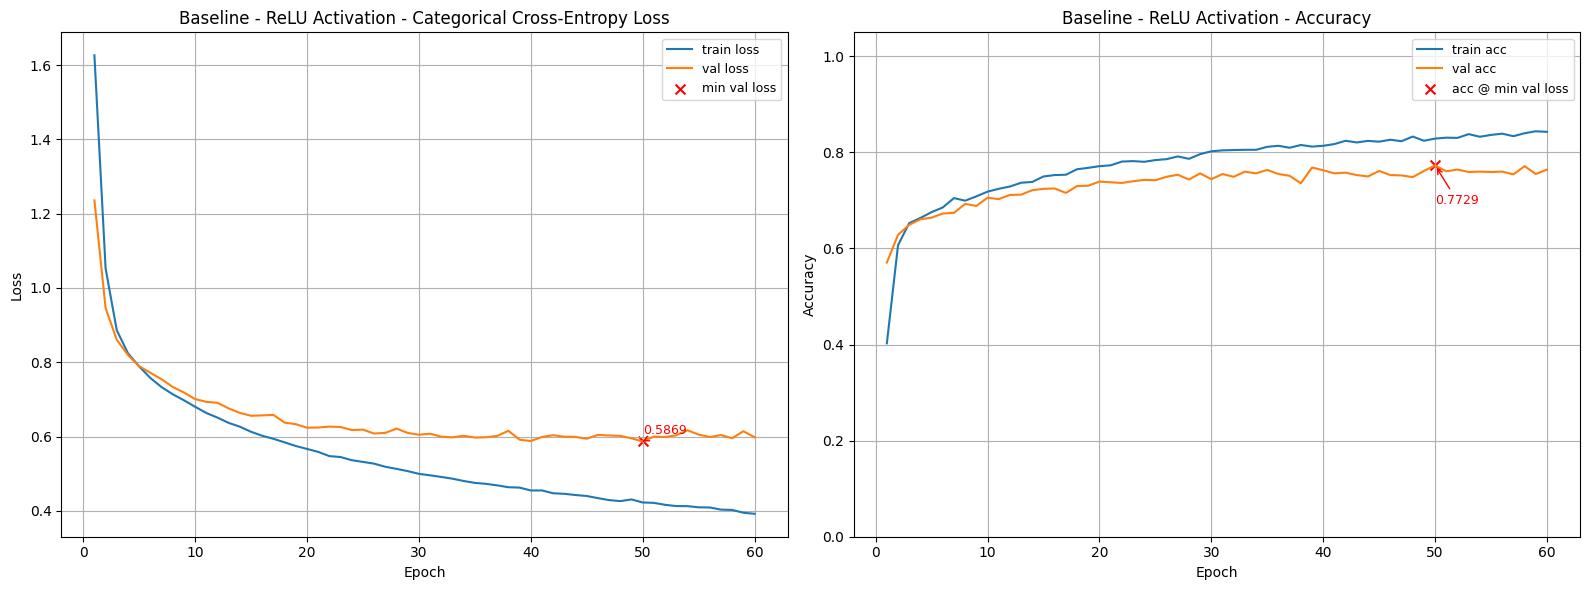

Final Training Loss:            0.3923
Final Training Accuracy:        0.8429
Final Validation Loss:          0.5984
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.5869 (Epoch 50)
Validation Accuracy @ Min Loss: 0.7729

Test Loss: 0.6075
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:14

Baseline - Sigmoid Activation



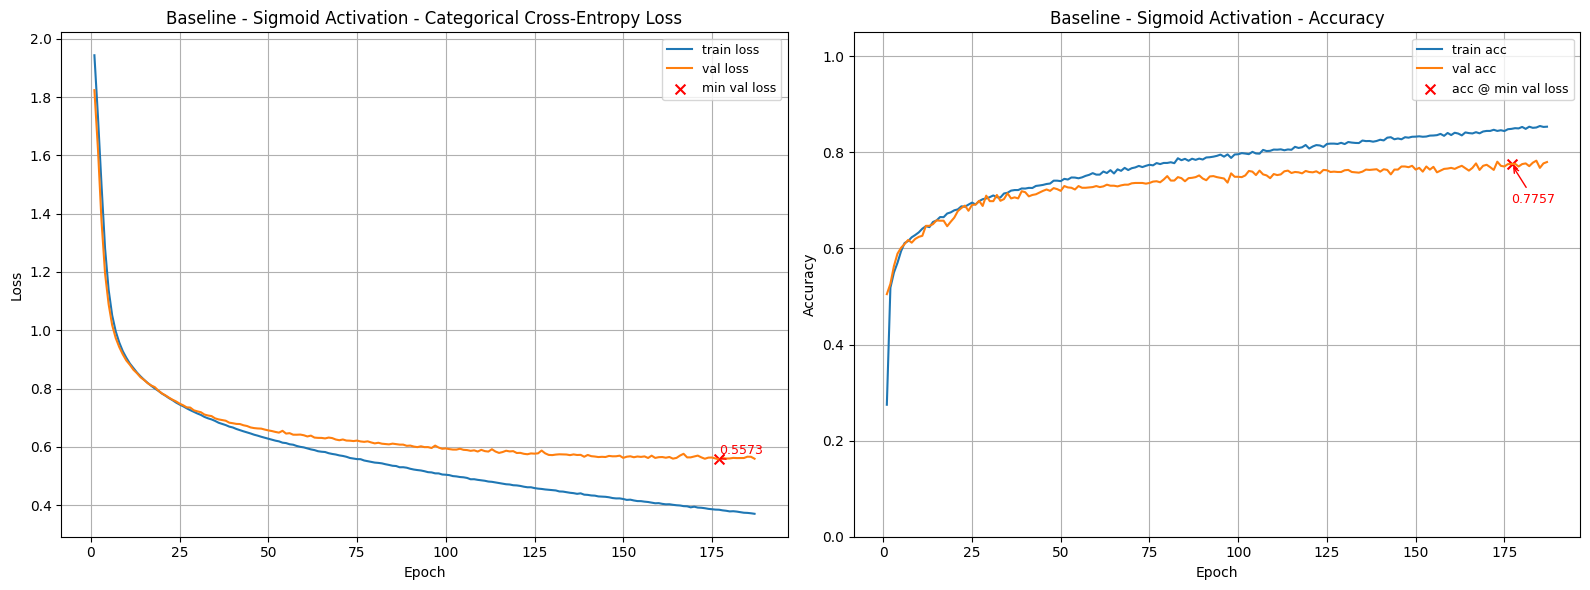

Final Training Loss:            0.3708
Final Training Accuracy:        0.8536
Final Validation Loss:          0.5596
Final Validation Accuracy:      0.7800
Minimum Validation Loss:        0.5573 (Epoch 177)
Validation Accuracy @ Min Loss: 0.7757

Test Loss: 0.5785
Test Accuracy: 0.7650

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:40

Baseline - Tanh Activation



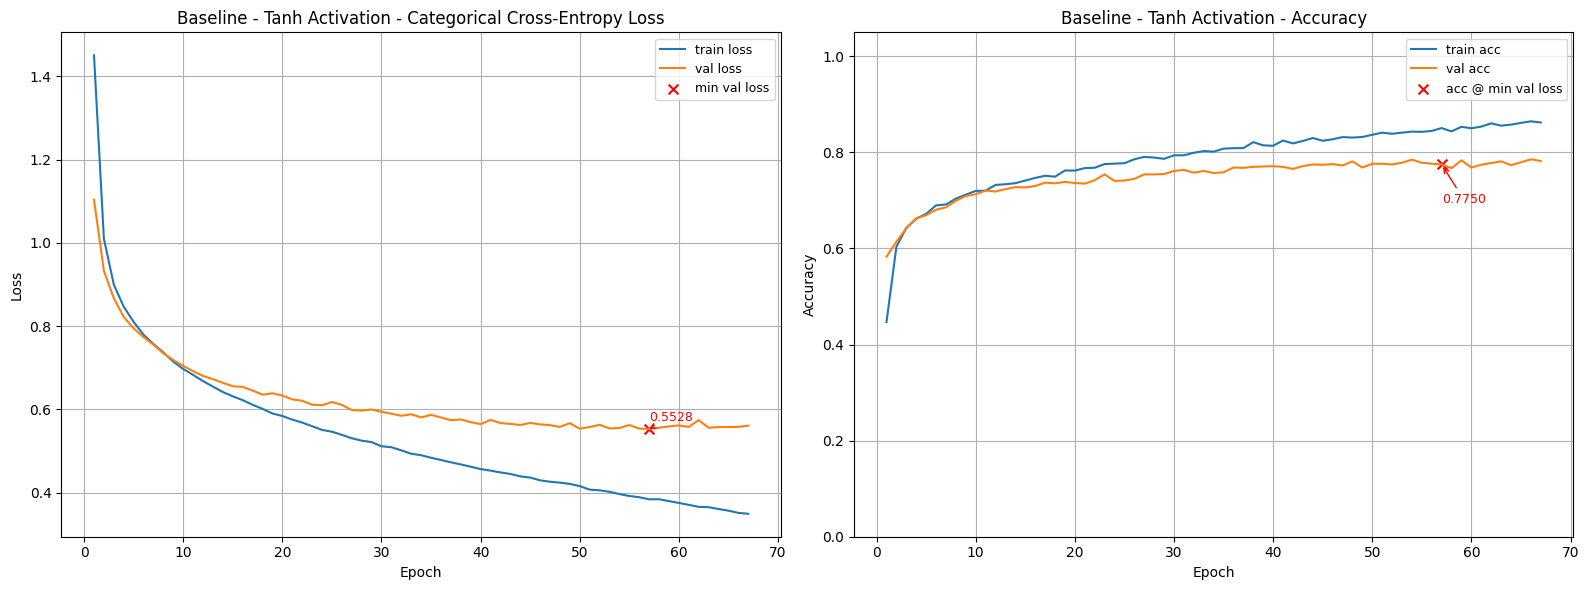

Final Training Loss:            0.3490
Final Training Accuracy:        0.8624
Final Validation Loss:          0.5607
Final Validation Accuracy:      0.7821
Minimum Validation Loss:        0.5528 (Epoch 57)
Validation Accuracy @ Min Loss: 0.7750

Test Loss: 0.5553
Test Accuracy: 0.7700

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:00:15


In [9]:

# At the top of Problem 1 cell
'''results_p1 = {}

# Temporarily override the global results (ugly but works)
original_results = results
results = results_p1'''


model_relu = build_model(
    X_train.shape[1],
    [
        (64, 'relu', 0.0, 0.0),
        (32, 'relu', 0.0, 0.0)
    ],
    n_classes
)

train_and_test(
    model_relu,
    title="Baseline - ReLU Activation"
)

## Sigmoid model 

model_sigmoid = build_model(
    X_train.shape[1],
    [
        (64, 'sigmoid', 0.0, 0.0),
        (32, 'sigmoid', 0.0, 0.0)
    ],
    n_classes
)

train_and_test(
    model_sigmoid,
    title="Baseline - Sigmoid Activation"
)


# tanh model 
model_tanh = build_model(
    X_train.shape[1],
    [
        (64, 'tanh', 0.0, 0.0),
        (32, 'tanh', 0.0, 0.0)
    ],
    n_classes
)

train_and_test(
    model_tanh,
    title="Baseline - Tanh Activation"
)
#results = original_results

activation_map = {
    "Baseline - ReLU Activation": 0,
    "Baseline - Sigmoid Activation": 1,
    "Baseline - Tanh Activation": 2
}

In [10]:
print_results()


Baseline - Sigmoid Activation           	0.7757
Baseline - Tanh Activation              	0.7750
Baseline - ReLU Activation              	0.7729


### Graded Questions

In [11]:
# Set a1a to the activation function which provided the best validation accuracy at the epoch of minimum validation loss

a1a = activation_map[max(results, key=lambda k: results[k][0])]   # 0=relu, 1=sigmoid, 2=tanh


In [12]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 1


In [13]:
# Set a1b to the validation accuracy found by this best activation function

a1b = max(results.values(), key=lambda v: v[0])[0]              # Replace with integer 0 (relu), 1 (sigmoid), or 2 (tanh)          # Replace 0.0 with your answer

In [14]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.7757


### Problem Two: Finding the Right Learning Rate

In this problem, you will continue working with the **baseline model** and determine which learning rate produces the best performance. As before, the model you evaluate should be the one saved by **early stopping** — the epoch where validation loss is minimized.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function identified in Problem One**.

* Train and evaluate this model using each of the following learning rates:

  ```
      [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
  ```

* Identify which learning rate produces the **best validation accuracy** at the epoch of **minimum validation loss**, within a maximum of **500 epochs**.

* Answer the graded questions.


**Note: Smaller learning rates will generally take more epochs to reach the optimal point, so some of these will not engage early stopping, but run the full 500 epochs.**



Training baseline model with learning rate = 0.001


Baseline - LR 0.001



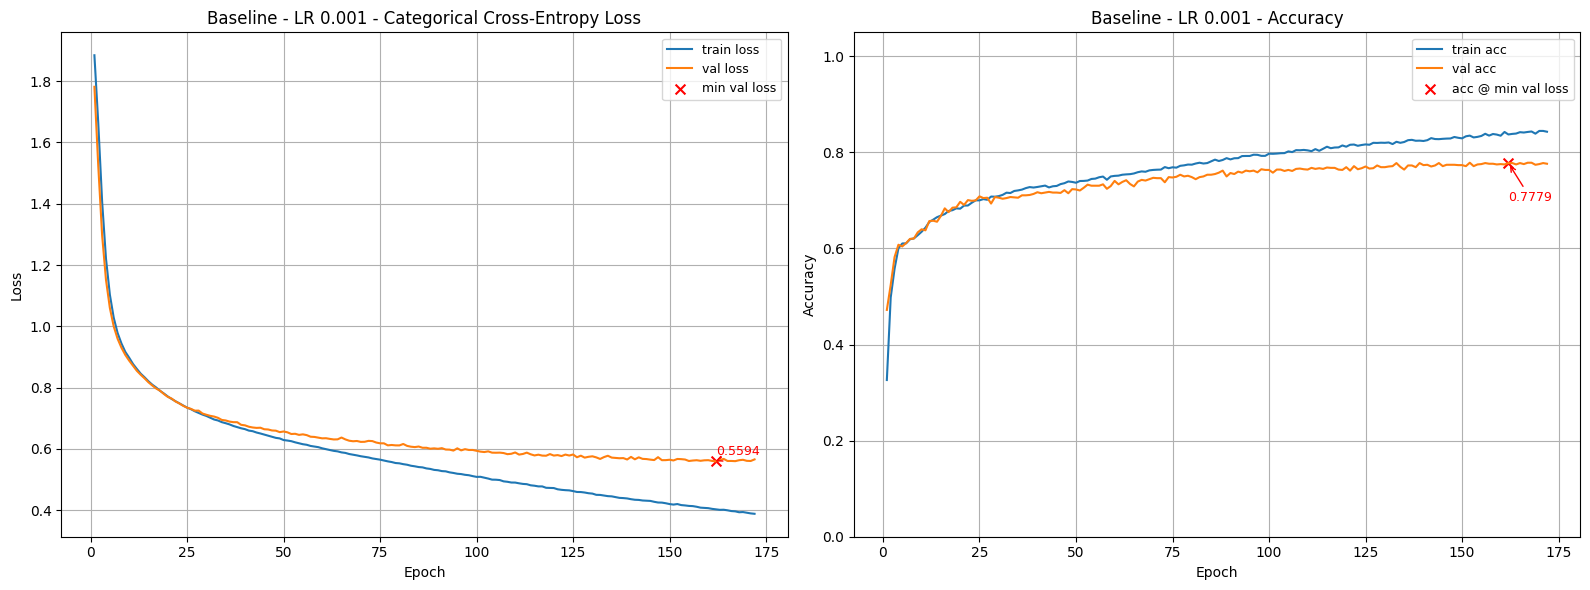

Final Training Loss:            0.3883
Final Training Accuracy:        0.8431
Final Validation Loss:          0.5658
Final Validation Accuracy:      0.7764
Minimum Validation Loss:        0.5594 (Epoch 162)
Validation Accuracy @ Min Loss: 0.7779

Test Loss: 0.5693
Test Accuracy: 0.7600

Validation-Test Gap (accuracy): 0.017857

Execution Time: 00:00:37

Training baseline model with learning rate = 0.0005


Baseline - LR 0.0005



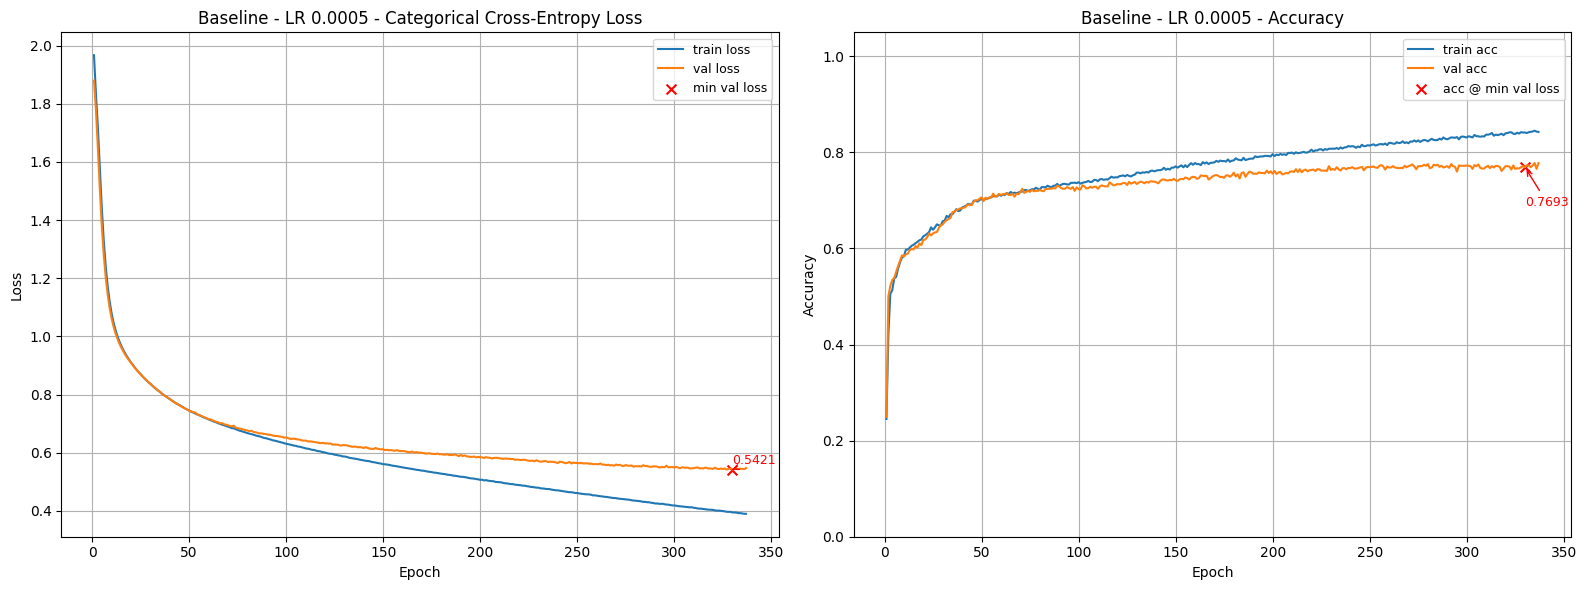

Final Training Loss:            0.3902
Final Training Accuracy:        0.8426
Final Validation Loss:          0.5473
Final Validation Accuracy:      0.7779
Minimum Validation Loss:        0.5421 (Epoch 330)
Validation Accuracy @ Min Loss: 0.7693

Test Loss: 0.5700
Test Accuracy: 0.7650

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:01:12

Training baseline model with learning rate = 0.0001


Baseline - LR 0.0001



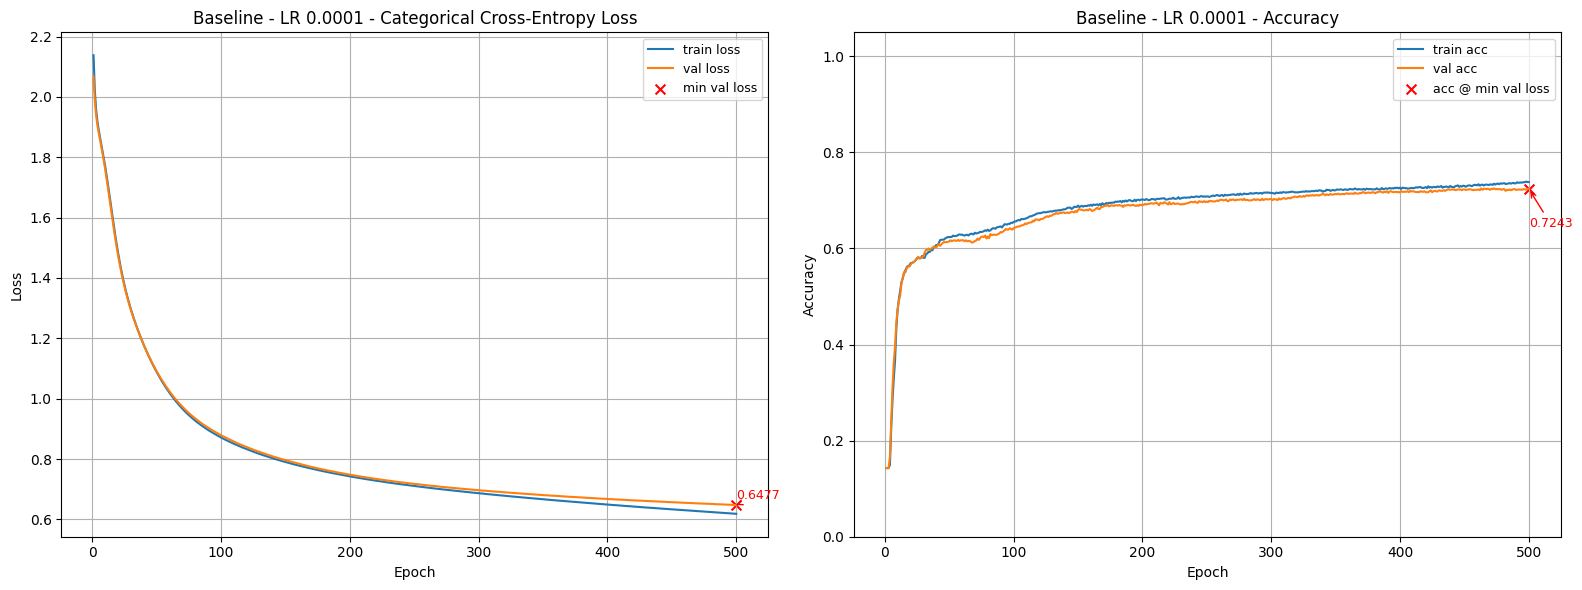

Final Training Loss:            0.6186
Final Training Accuracy:        0.7383
Final Validation Loss:          0.6477
Final Validation Accuracy:      0.7243
Minimum Validation Loss:        0.6477 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7243

Test Loss: 0.6720
Test Accuracy: 0.7164

Validation-Test Gap (accuracy): 0.007857

Execution Time: 00:01:47

Training baseline model with learning rate = 5e-05


Baseline - LR 5e-05



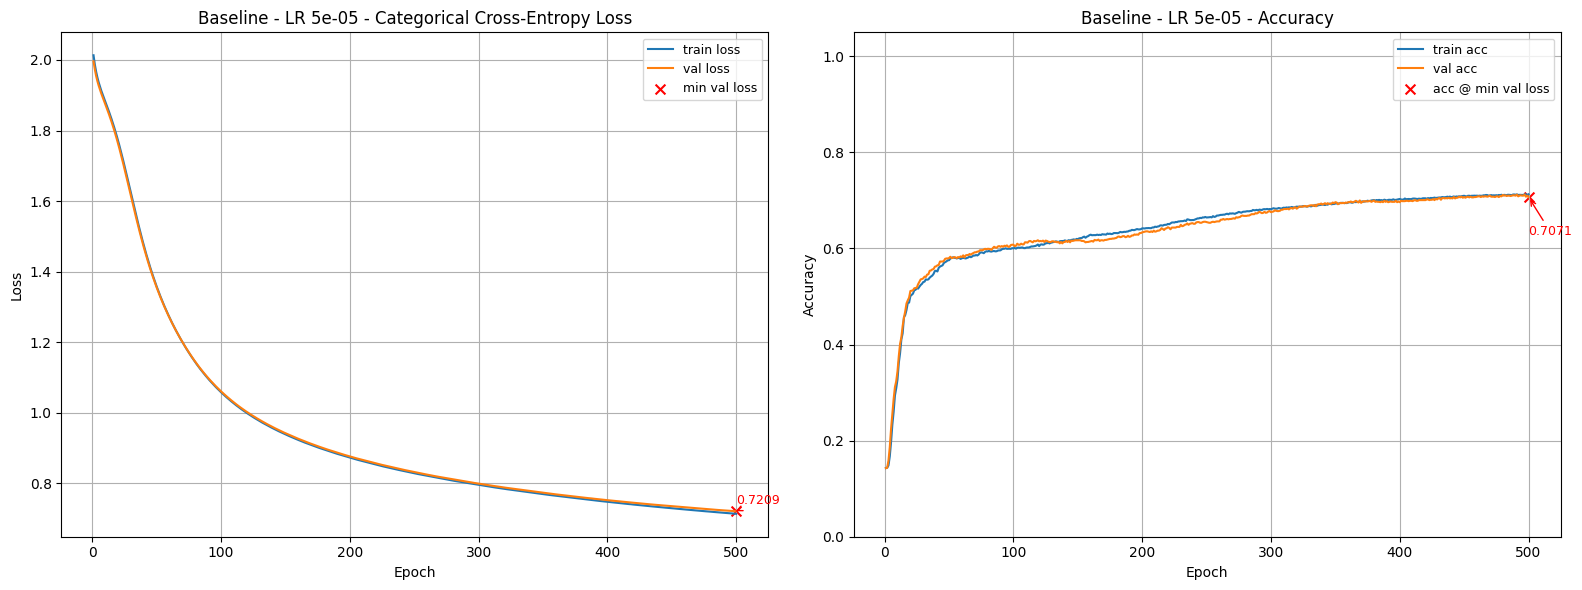

Final Training Loss:            0.7137
Final Training Accuracy:        0.7129
Final Validation Loss:          0.7209
Final Validation Accuracy:      0.7071
Minimum Validation Loss:        0.7209 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7071

Test Loss: 0.7415
Test Accuracy: 0.6929

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:01:46

Training baseline model with learning rate = 1e-05


Baseline - LR 1e-05



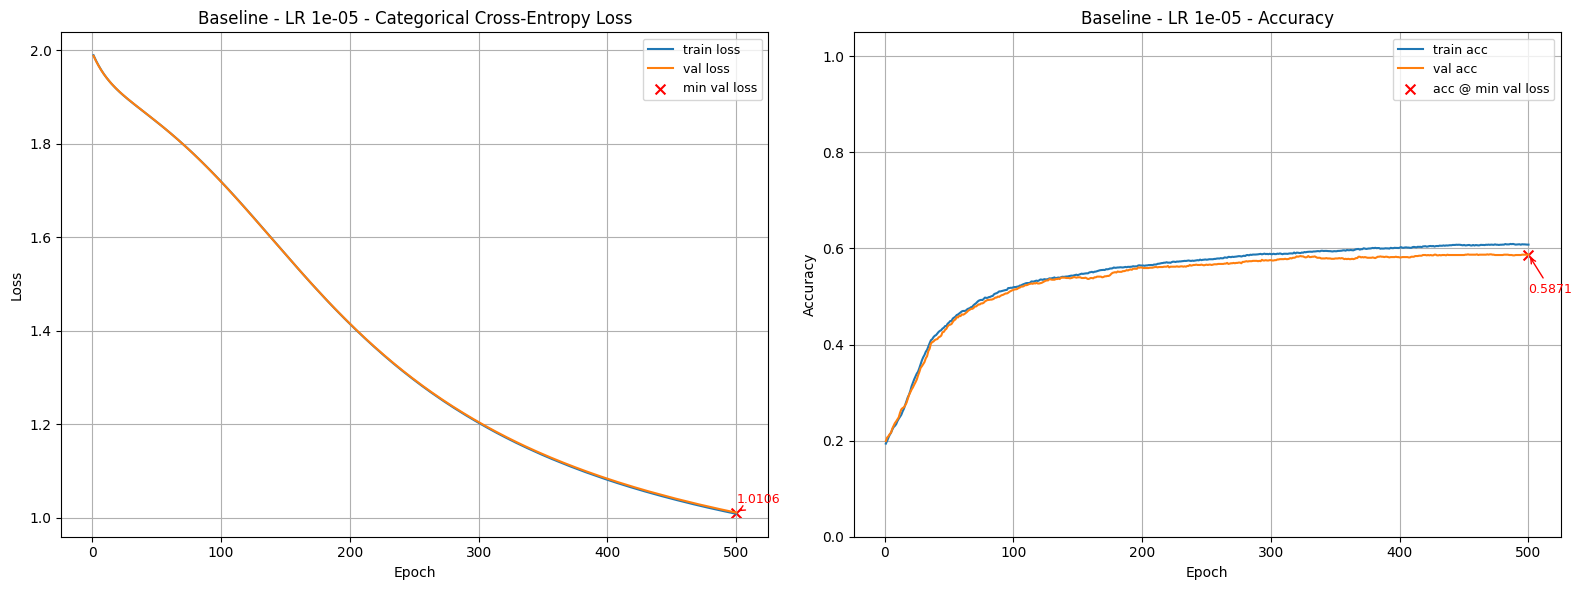

Final Training Loss:            1.0081
Final Training Accuracy:        0.6081
Final Validation Loss:          1.0106
Final Validation Accuracy:      0.5871
Minimum Validation Loss:        1.0106 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5871

Test Loss: 1.0084
Test Accuracy: 0.6193

Validation-Test Gap (accuracy): 0.032143

Execution Time: 00:01:46

Validation accuracies for different learning rates:
LR=0.001000 -> Val Acc=0.7779
LR=0.000500 -> Val Acc=0.7693
LR=0.000100 -> Val Acc=0.7243
LR=0.000050 -> Val Acc=0.7071
LR=0.000010 -> Val Acc=0.5871


In [15]:
# Your code here. Add as many cells as you need. 

# Best activation from Problem 1
#best_activation = 'relu'

# Map a1a (from Problem 1) to activation name
activation_name_map = {0: 'relu', 1: 'sigmoid', 2: 'tanh'}
best_activation = activation_name_map[a1a]

# Learning rates to test
learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]

# Dictionary to store results
lr_results = {}

for lr in learning_rates:
    print(f"\nTraining baseline model with learning rate = {lr}\n")
    
    # Build baseline model
    model_lr = build_model(
        X_train.shape[1],
        [
            (64, best_activation, 0.0, 0.0),
            (32, best_activation, 0.0, 0.0)
        ],
        n_classes
    )
    
    # Train and evaluate
    history = train_and_test(
        model_lr,
        lr_schedule=lr,
        title=f"Baseline - LR {lr}",
        verbose=0
    )
    
    # Record validation accuracy at min val loss
    lr_results[lr] = results[f"Baseline - LR {lr}"][0]

# Print all results sorted by accuracy
sorted_lrs = sorted(lr_results.items(), key=lambda x: x[1], reverse=True)
print("\nValidation accuracies for different learning rates:")
for lr, acc in sorted_lrs:
    print(f"LR={lr:.6f} -> Val Acc={acc:.4f}")


#### Graded Questions

In [16]:
# Set a2a to the learning rate which provided the best validation accuracy at the epoch of minimum validation loss

a2a =max(lr_results, key=lambda lr: lr_results[lr])
          # Replace 0.0 with your answer

In [17]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.6f}') 

a2a = 0.001000


In [18]:
# Set a2b to the validation accuracy found by this best learning rate

a2b = lr_results[a2a]            # Replace 0.0 with your answer

In [19]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7779


### Problem Three: Dropout

In this problem, you will explore how **dropout** can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Dropout typically works best in **later dense layers** (e.g., the second hidden layer of width 32) in the range **0.3–0.5**.
* If applied to **earlier layers** (e.g., the first hidden layer), dropout should be smaller, typically **0.0–0.2** (where 0.0 means no dropout).

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate dropout in the ranges suggested, using increments of **0.1**.
* Identify which dropout configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Training model with Dropout (64:0.0, 32:0.3)

Dropout 64:0.0-32:0.3



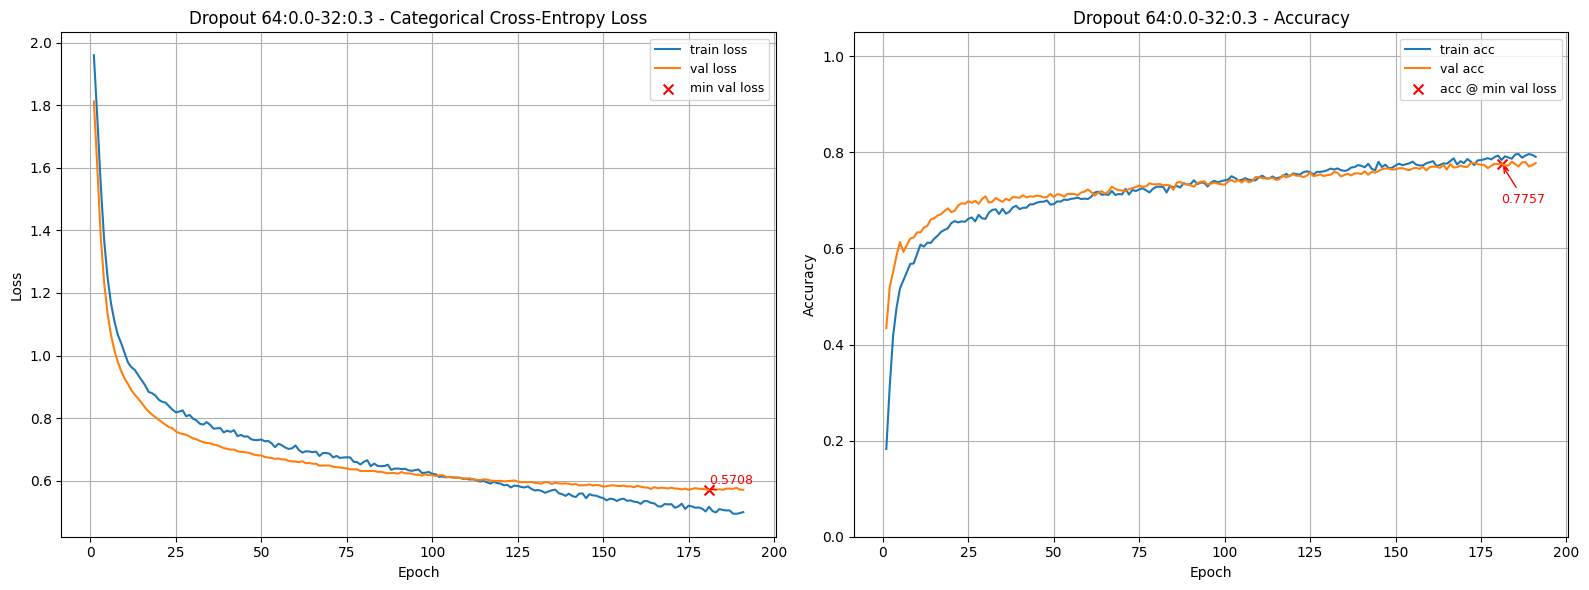

Final Training Loss:            0.5002
Final Training Accuracy:        0.7910
Final Validation Loss:          0.5715
Final Validation Accuracy:      0.7779
Minimum Validation Loss:        0.5708 (Epoch 181)
Validation Accuracy @ Min Loss: 0.7757

Test Loss: 0.6003
Test Accuracy: 0.7550

Validation-Test Gap (accuracy): 0.020714

Execution Time: 00:00:41

Training model with Dropout (64:0.0, 32:0.4)

Dropout 64:0.0-32:0.4



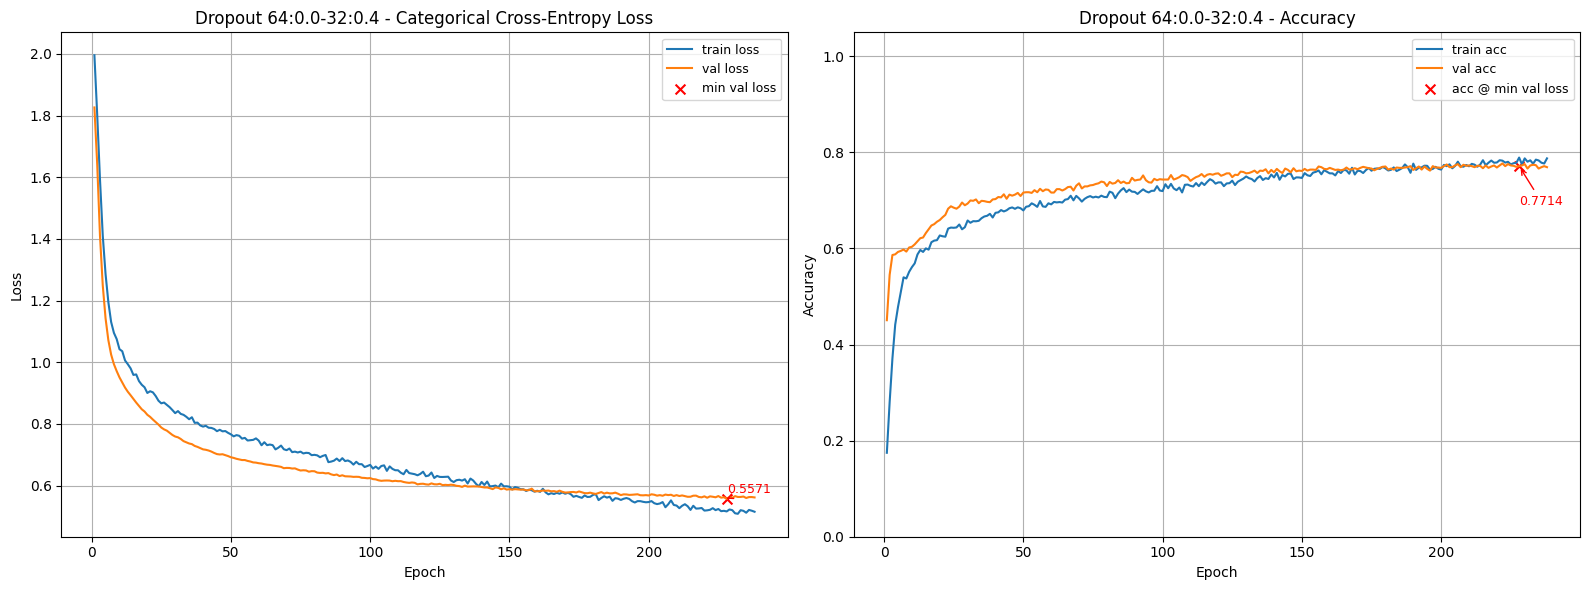

Final Training Loss:            0.5151
Final Training Accuracy:        0.7876
Final Validation Loss:          0.5616
Final Validation Accuracy:      0.7693
Minimum Validation Loss:        0.5571 (Epoch 228)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.5966
Test Accuracy: 0.7529

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:51

Training model with Dropout (64:0.0, 32:0.5)

Dropout 64:0.0-32:0.5



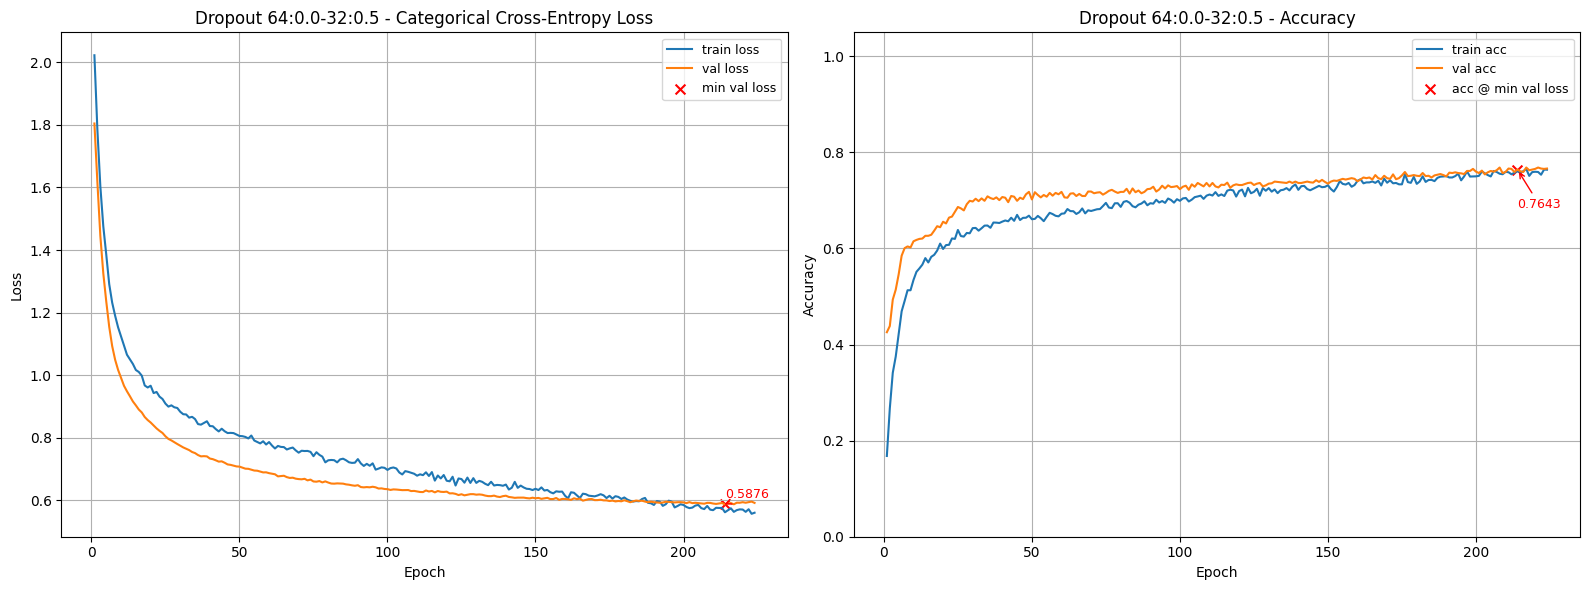

Final Training Loss:            0.5610
Final Training Accuracy:        0.7640
Final Validation Loss:          0.5923
Final Validation Accuracy:      0.7664
Minimum Validation Loss:        0.5876 (Epoch 214)
Validation Accuracy @ Min Loss: 0.7643

Test Loss: 0.6295
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.008571

Execution Time: 00:00:48

Training model with Dropout (64:0.1, 32:0.3)

Dropout 64:0.1-32:0.3



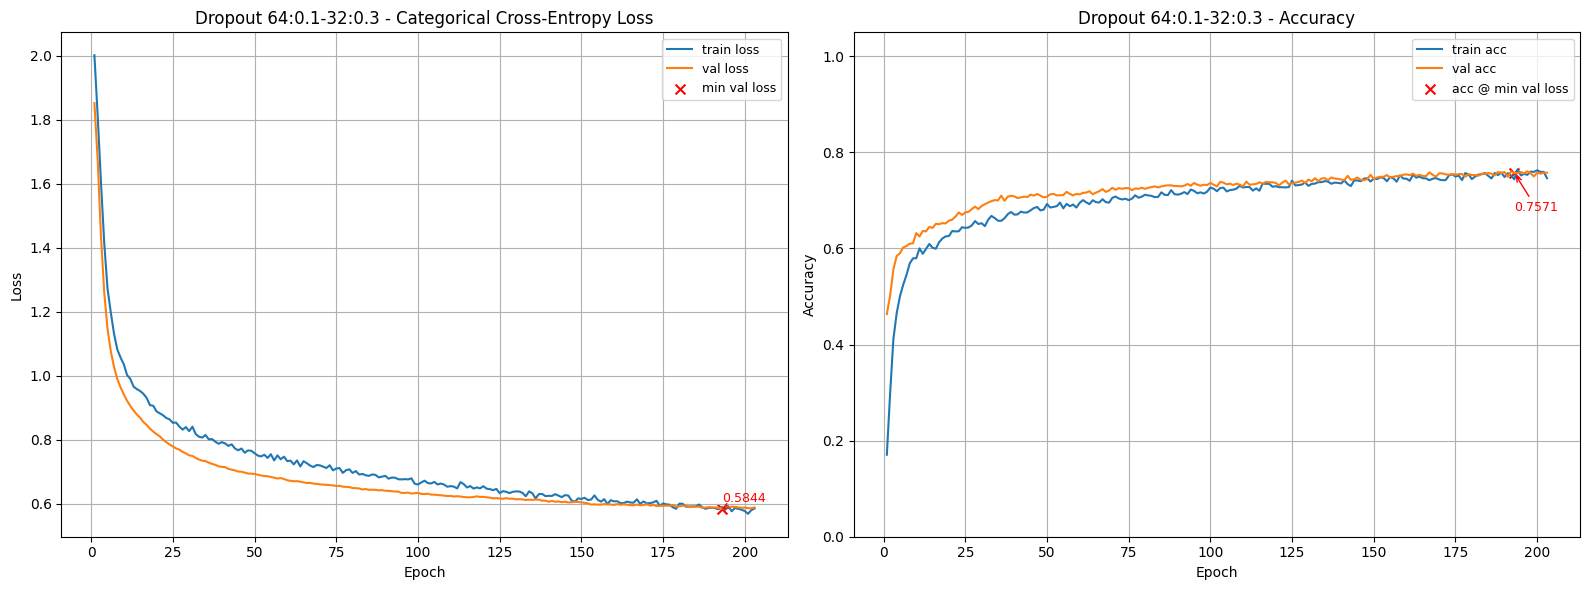

Final Training Loss:            0.5848
Final Training Accuracy:        0.7464
Final Validation Loss:          0.5879
Final Validation Accuracy:      0.7579
Minimum Validation Loss:        0.5844 (Epoch 193)
Validation Accuracy @ Min Loss: 0.7571

Test Loss: 0.6052
Test Accuracy: 0.7400

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:45

Training model with Dropout (64:0.1, 32:0.4)

Dropout 64:0.1-32:0.4



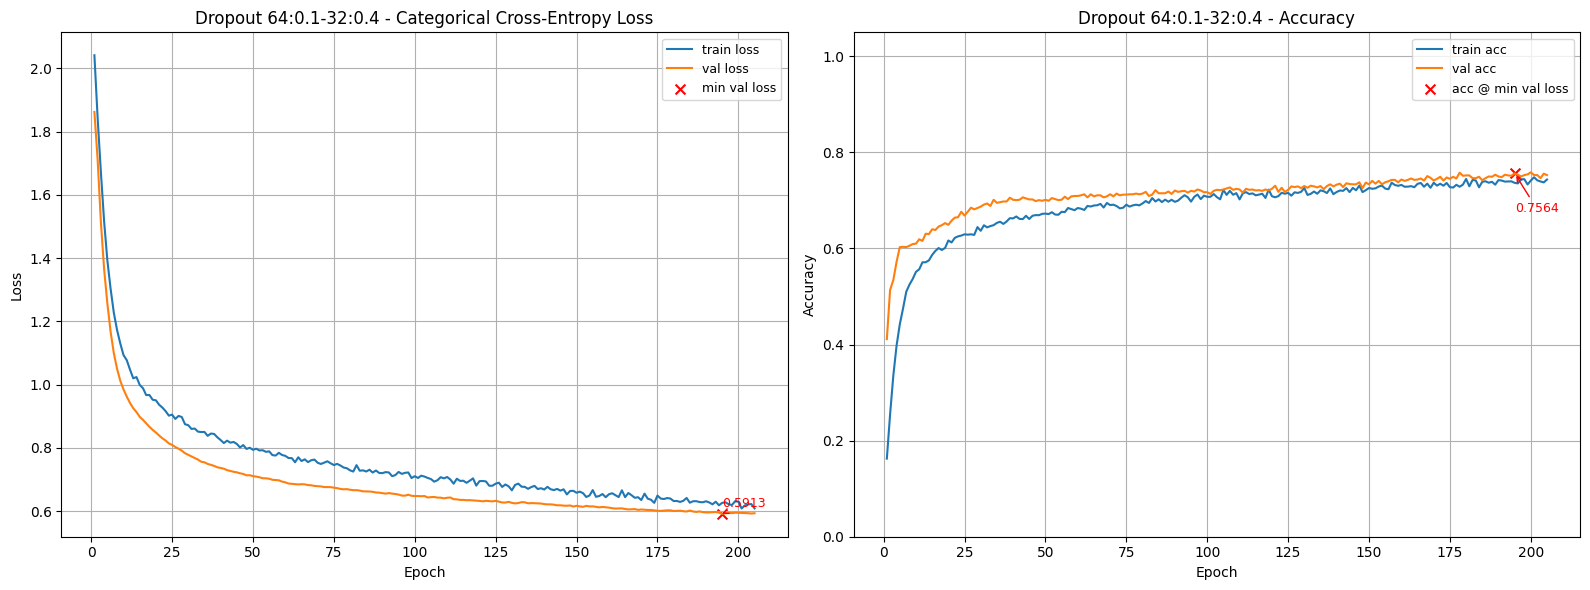

Final Training Loss:            0.6084
Final Training Accuracy:        0.7436
Final Validation Loss:          0.5930
Final Validation Accuracy:      0.7529
Minimum Validation Loss:        0.5913 (Epoch 195)
Validation Accuracy @ Min Loss: 0.7564

Test Loss: 0.6182
Test Accuracy: 0.7421

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:00:45

Training model with Dropout (64:0.1, 32:0.5)

Dropout 64:0.1-32:0.5



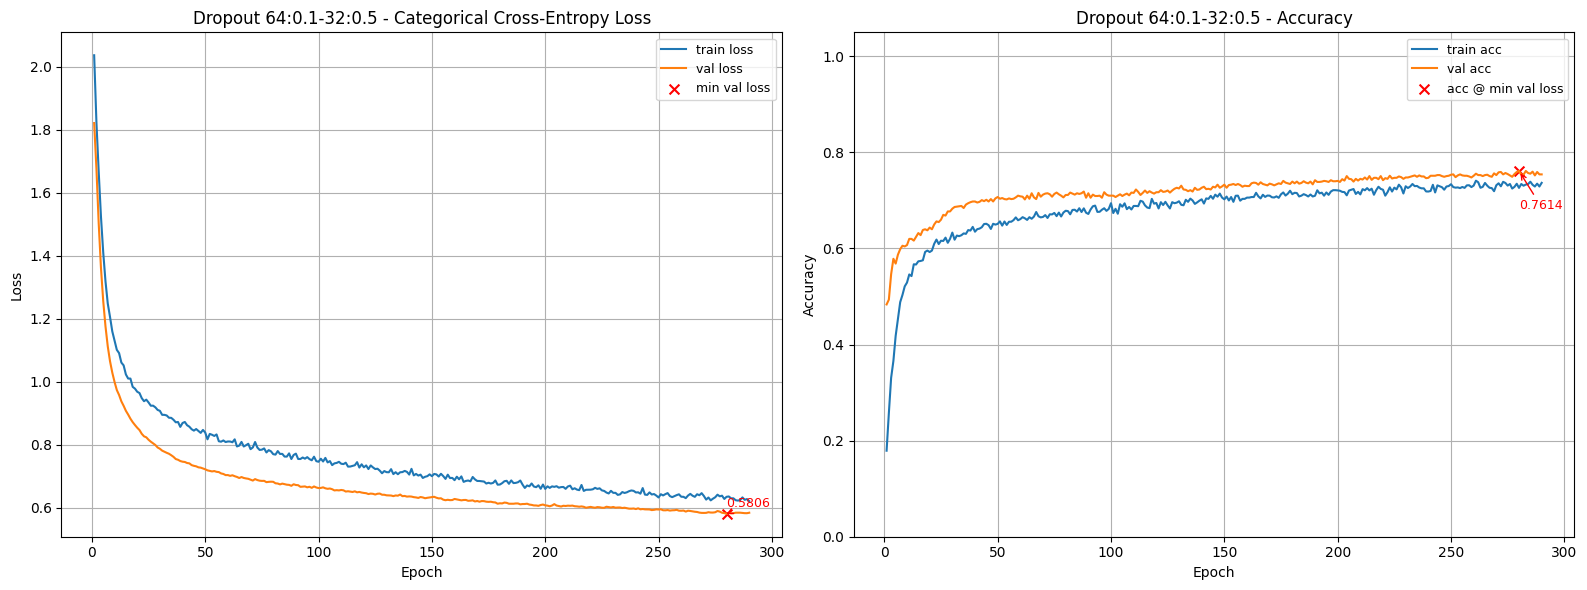

Final Training Loss:            0.6207
Final Training Accuracy:        0.7367
Final Validation Loss:          0.5840
Final Validation Accuracy:      0.7543
Minimum Validation Loss:        0.5806 (Epoch 280)
Validation Accuracy @ Min Loss: 0.7614

Test Loss: 0.6112
Test Accuracy: 0.7479

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:01:03

Training model with Dropout (64:0.2, 32:0.3)

Dropout 64:0.2-32:0.3



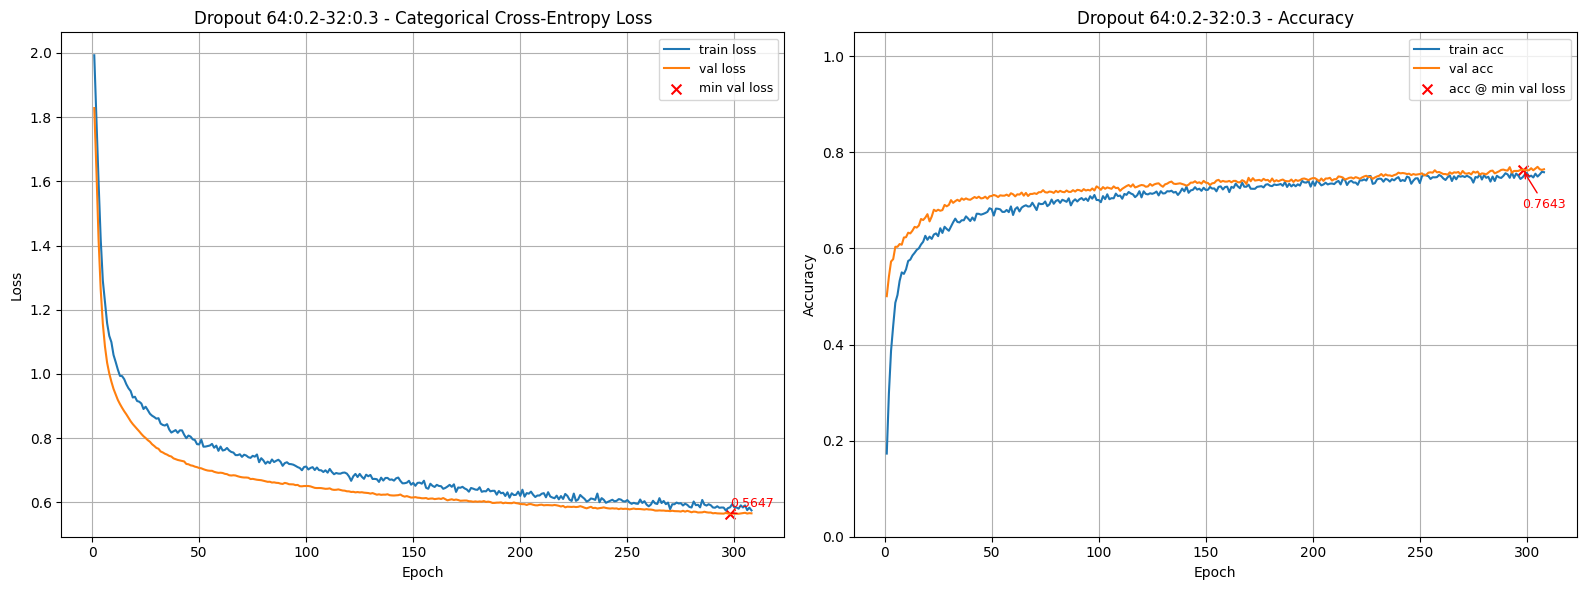

Final Training Loss:            0.5752
Final Training Accuracy:        0.7588
Final Validation Loss:          0.5661
Final Validation Accuracy:      0.7650
Minimum Validation Loss:        0.5647 (Epoch 298)
Validation Accuracy @ Min Loss: 0.7643

Test Loss: 0.5890
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.008571

Execution Time: 00:01:08

Training model with Dropout (64:0.2, 32:0.4)

Dropout 64:0.2-32:0.4



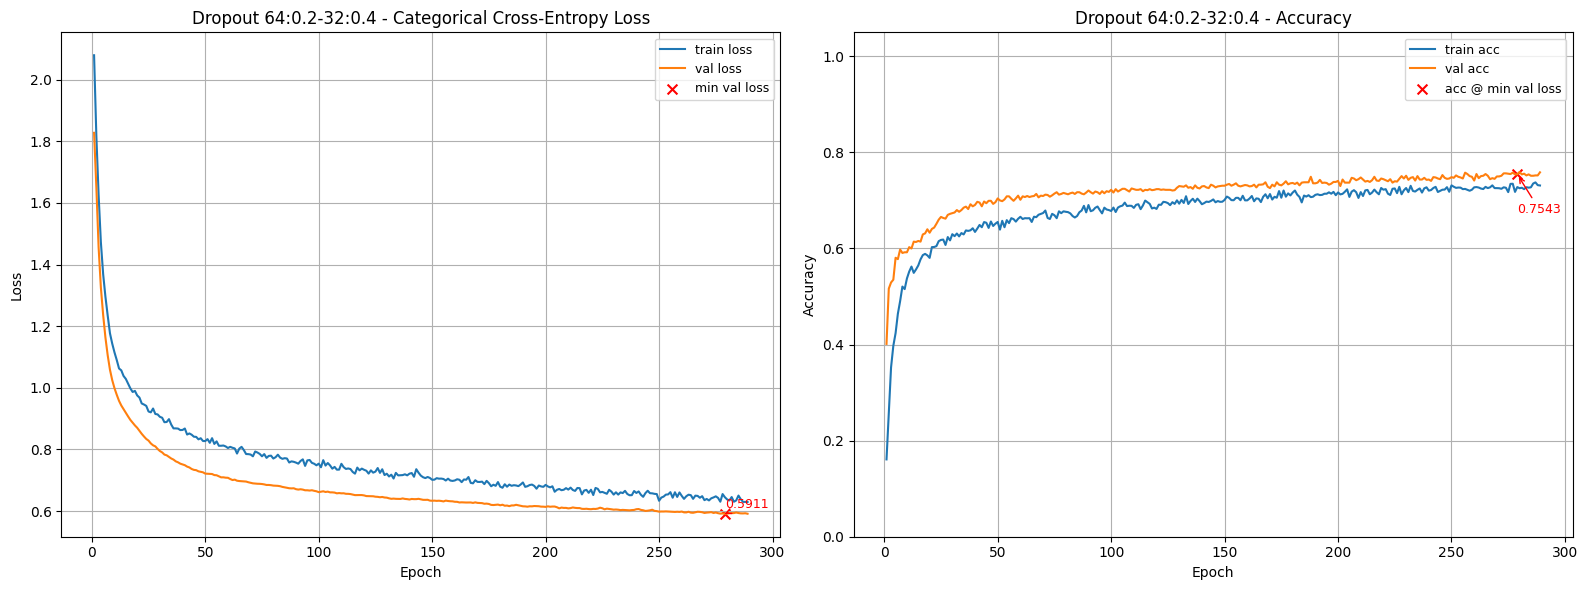

Final Training Loss:            0.6296
Final Training Accuracy:        0.7312
Final Validation Loss:          0.5913
Final Validation Accuracy:      0.7586
Minimum Validation Loss:        0.5911 (Epoch 279)
Validation Accuracy @ Min Loss: 0.7543

Test Loss: 0.6130
Test Accuracy: 0.7393

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:01:06

Training model with Dropout (64:0.2, 32:0.5)

Dropout 64:0.2-32:0.5



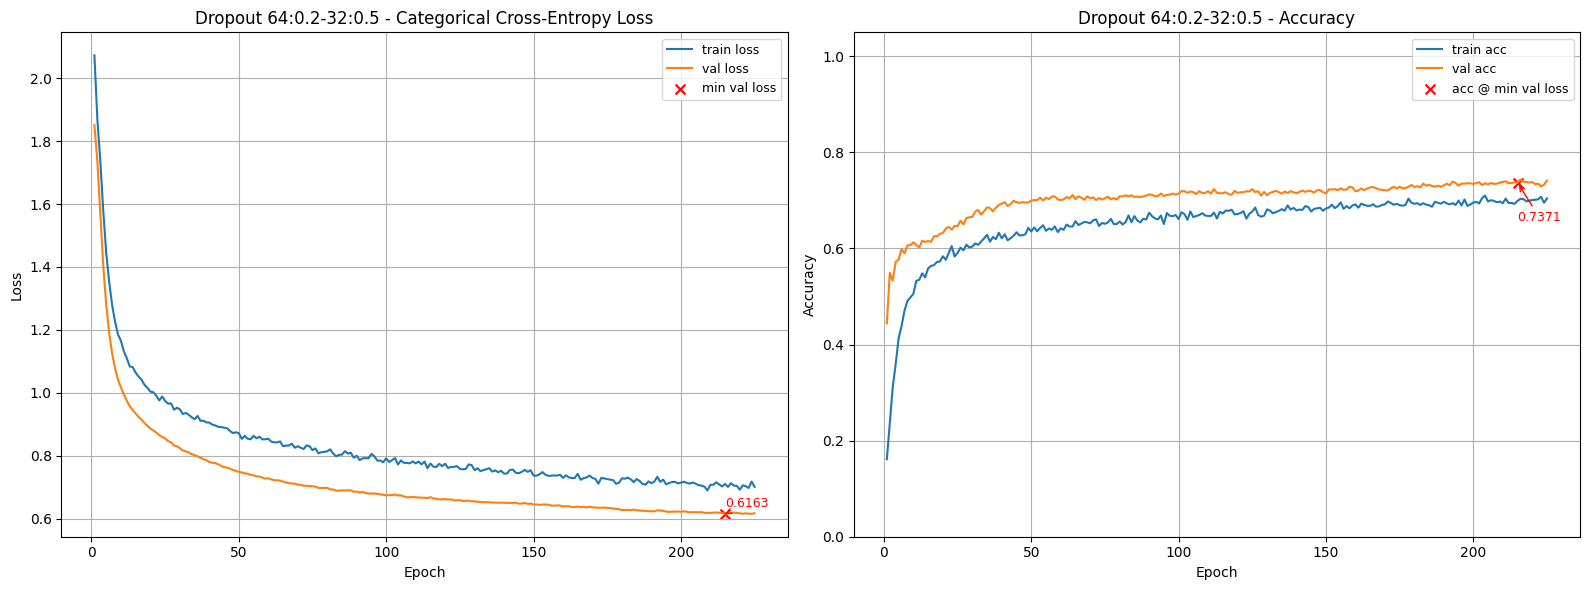

Final Training Loss:            0.7019
Final Training Accuracy:        0.7043
Final Validation Loss:          0.6178
Final Validation Accuracy:      0.7414
Minimum Validation Loss:        0.6163 (Epoch 215)
Validation Accuracy @ Min Loss: 0.7371

Test Loss: 0.6409
Test Accuracy: 0.7207

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:00:51

Best Dropout Configuration:
Dropout rates (64 units, 32 units): (0.0, 0.3)
Validation Accuracy: 0.7757


In [20]:
# Map activation index from Problem 1 to name
activation_name_map = {0: 'relu', 1: 'sigmoid', 2: 'tanh'}
best_activation = activation_name_map[a1a]

# Best learning rate from Problem 2
best_lr = a2a

# Dropout ranges
dropout_64_options = [0.0, 0.1, 0.2]
dropout_32_options = [0.3, 0.4, 0.5]

best_dropout_acc = 0.0
best_dropout_pair = (0.0, 0.0)

for d1 in dropout_64_options:
    for d2 in dropout_32_options:
        print(f"\nTraining model with Dropout (64:{d1}, 32:{d2})")
        
        model_dropout = build_model(
            X_train.shape[1],
            [
                (64, best_activation, 0.0, d1),
                (32, best_activation, 0.0, d2)
            ],
            n_classes
        )
        
        history = train_and_test(
            model_dropout,
            lr_schedule=best_lr,
            title=f"Dropout 64:{d1}-32:{d2}",
            verbose=0
        )
        
        val_acc = results[f"Dropout 64:{d1}-32:{d2}"][0]
        
        if val_acc > best_dropout_acc:
            best_dropout_acc = val_acc
            best_dropout_pair = (d1, d2)

print("\nBest Dropout Configuration:")
print(f"Dropout rates (64 units, 32 units): {best_dropout_pair}")
print(f"Validation Accuracy: {best_dropout_acc:.4f}")


In [21]:
# Set a3a to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a3a =  best_dropout_pair           # Replace (0.0,0.0) with your answer

In [22]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 

a3a = (0.0, 0.3)


In [23]:
# Set a3b to the validation accuracy found by this best pair of dropout rates

a3b = best_dropout_acc           # Replace 0.0 with your answer

In [24]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.7757


### Problem Four: L2 Regularization

In this problem, you will explore how **L2 regularization** (also called *weight decay*) can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Start simple by using the **same λ in both hidden layers**, with values:

  ```
      1e-4, 1e-3, 1e-2
  ```

* If validation results suggest underfitting in the first layer or persistent overfitting in the later one, then try adjusting per layer, for example:

  * First hidden layer: λ = 1e-4
  * Second hidden layer: λ = 1e-3

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**, but **without dropout**.
* Investigate at least the four cases suggested (three with the same λ and one with different λ values). You may also consider additional combinations.
* Identify which configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Training model with L2 λ=0.0001 for both layers

L2 λ=0.0001



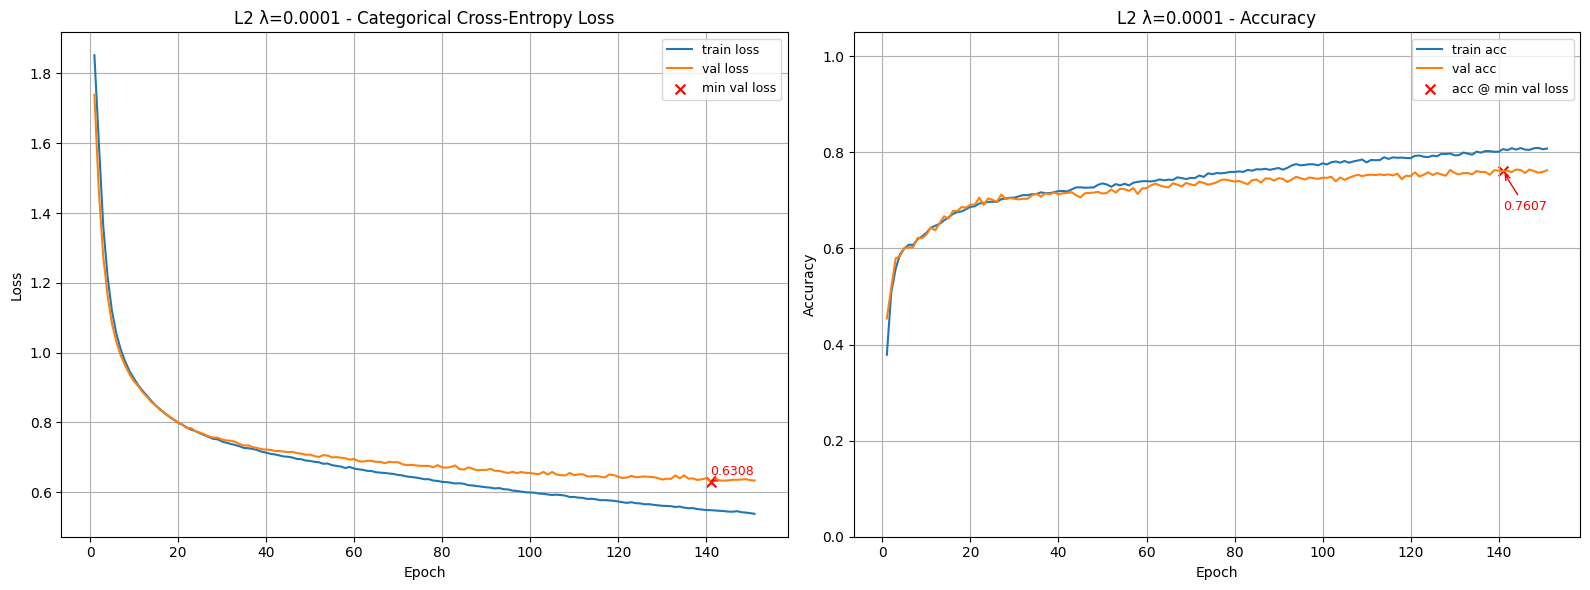

Final Training Loss:            0.5383
Final Training Accuracy:        0.8081
Final Validation Loss:          0.6339
Final Validation Accuracy:      0.7629
Minimum Validation Loss:        0.6308 (Epoch 141)
Validation Accuracy @ Min Loss: 0.7607

Test Loss: 0.6523
Test Accuracy: 0.7536

Validation-Test Gap (accuracy): 0.007143

Execution Time: 00:00:33

Training model with L2 λ=0.001 for both layers

L2 λ=0.001



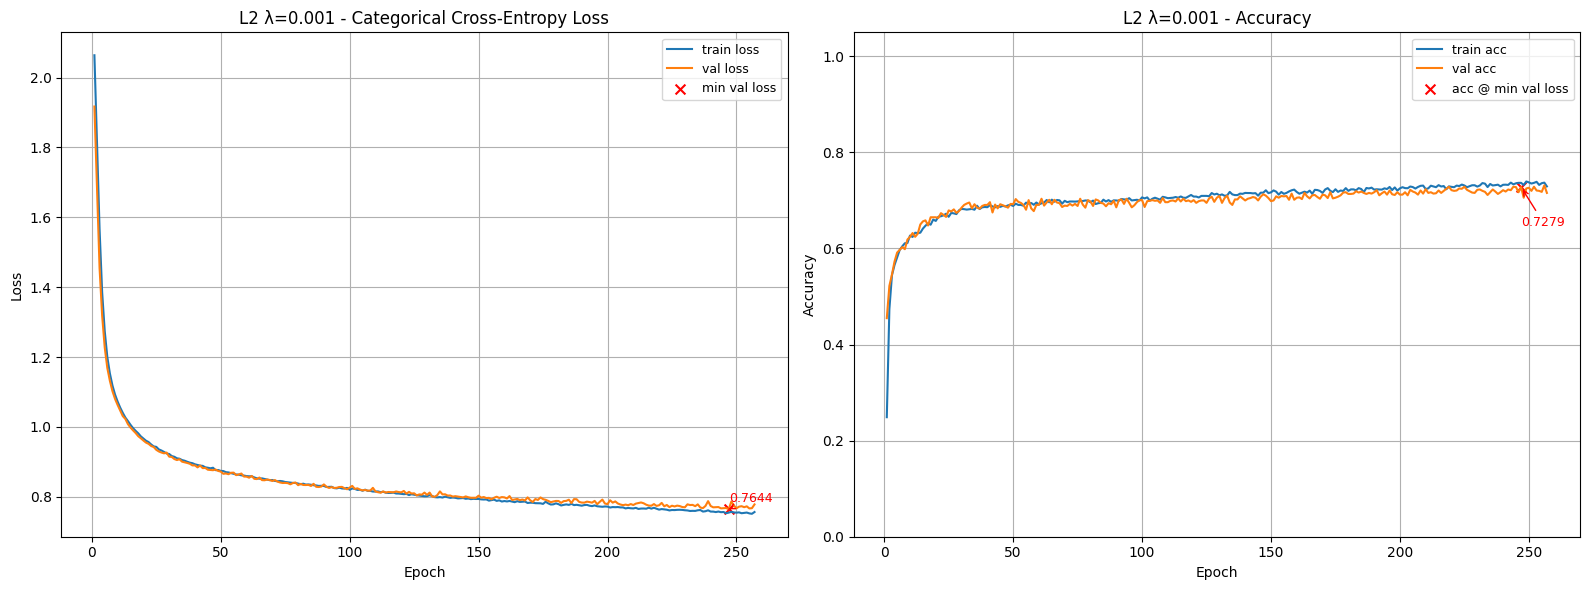

Final Training Loss:            0.7564
Final Training Accuracy:        0.7293
Final Validation Loss:          0.7782
Final Validation Accuracy:      0.7157
Minimum Validation Loss:        0.7644 (Epoch 247)
Validation Accuracy @ Min Loss: 0.7279

Test Loss: 0.7878
Test Accuracy: 0.7200

Validation-Test Gap (accuracy): 0.007857

Execution Time: 00:00:56

Training model with L2 λ=0.01 for both layers

L2 λ=0.01



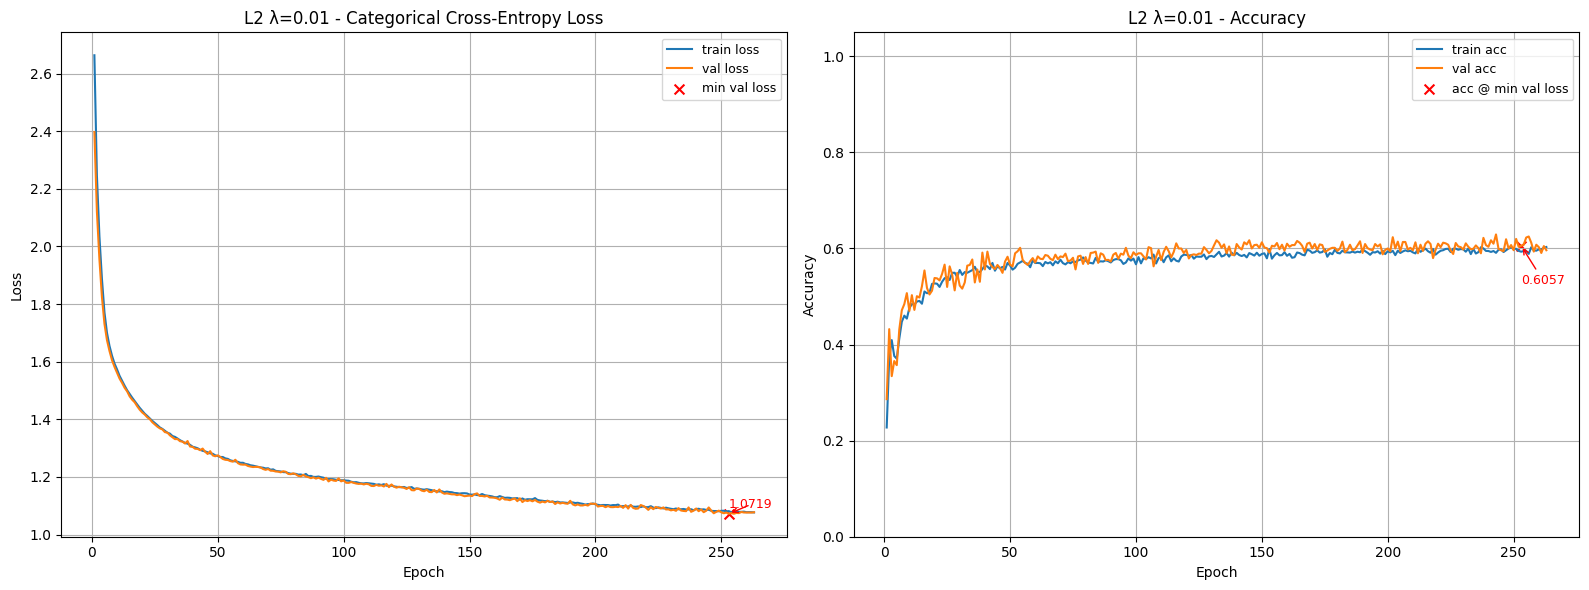

Final Training Loss:            1.0767
Final Training Accuracy:        0.6031
Final Validation Loss:          1.0772
Final Validation Accuracy:      0.5964
Minimum Validation Loss:        1.0719 (Epoch 253)
Validation Accuracy @ Min Loss: 0.6057

Test Loss: 1.0836
Test Accuracy: 0.5950

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:56

Training model with L2 λ=0.0001 (64), λ=0.001 (32)

L2 λ64:0.0001-32:0.001



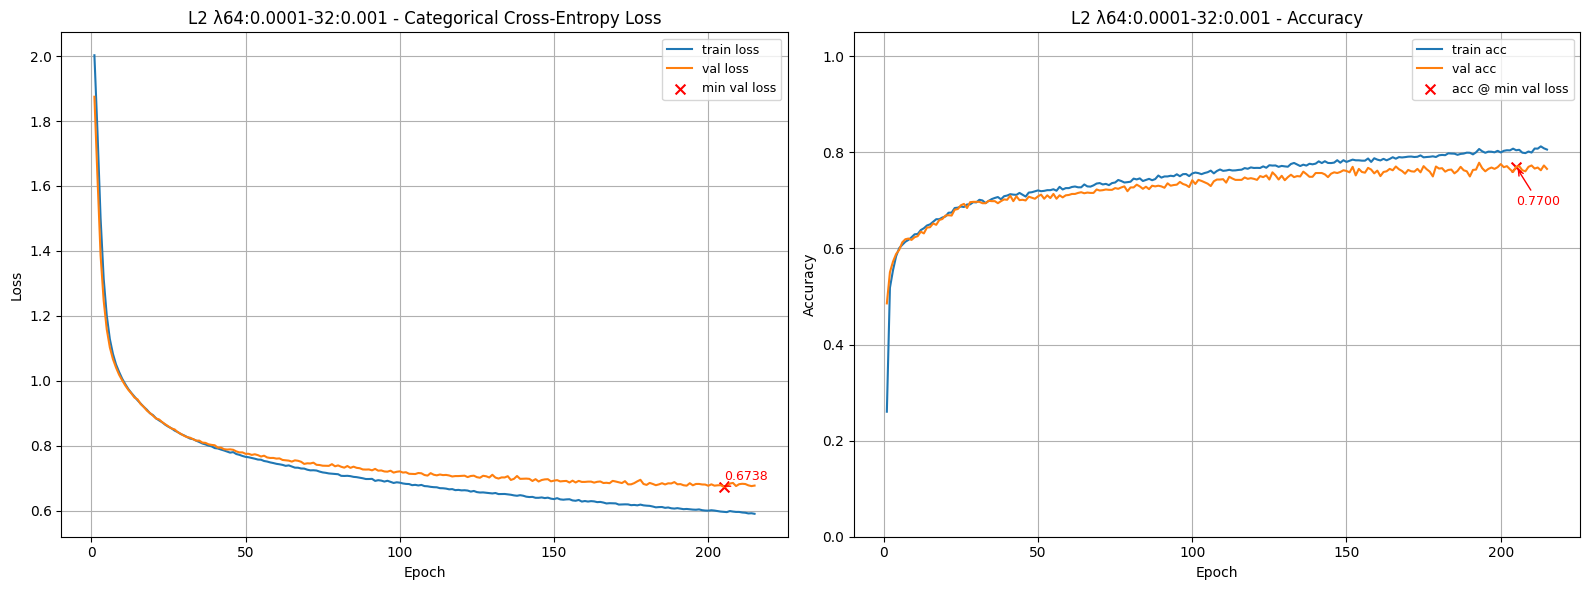

Final Training Loss:            0.5903
Final Training Accuracy:        0.8060
Final Validation Loss:          0.6771
Final Validation Accuracy:      0.7657
Minimum Validation Loss:        0.6738 (Epoch 205)
Validation Accuracy @ Min Loss: 0.7700

Test Loss: 0.6899
Test Accuracy: 0.7643

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:00:46

Best L2 Configuration:
L2 lambdas (64 units, 32 units): (0.0001, 0.001)
Validation Accuracy: 0.7700


In [25]:
# Map activation index from Problem 1 to name
activation_name_map = {0: 'relu', 1: 'sigmoid', 2: 'tanh'}
best_activation = activation_name_map[a1a]

# Best learning rate from Problem 2
best_lr = a2a

# L2 regularization options
l2_options_same = [1e-4, 1e-3, 1e-2]
l2_options_mixed = [(1e-4, 1e-3)]

best_l2_acc = 0.0
best_l2_pair = (0.0, 0.0)

# 1) Same lambda for both layers
for l2_val in l2_options_same:
    print(f"\nTraining model with L2 λ={l2_val} for both layers")
    
    model_l2 = build_model(
        X_train.shape[1],
        [
            (64, best_activation, l2_val, 0.0),
            (32, best_activation, l2_val, 0.0)
        ],
        n_classes
    )
    
    history = train_and_test(
        model_l2,
        lr_schedule=best_lr,
        title=f"L2 λ={l2_val}",
        verbose=0
    )
    
    val_acc = results[f"L2 λ={l2_val}"][0]
    if val_acc > best_l2_acc:
        best_l2_acc = val_acc
        best_l2_pair = (l2_val, l2_val)

# 2) Mixed lambda
for l2_pair in l2_options_mixed:
    print(f"\nTraining model with L2 λ={l2_pair[0]} (64), λ={l2_pair[1]} (32)")
    
    model_l2 = build_model(
        X_train.shape[1],
        [
            (64, best_activation, l2_pair[0], 0.0),
            (32, best_activation, l2_pair[1], 0.0)
        ],
        n_classes
    )
    
    history = train_and_test(
        model_l2,
        lr_schedule=best_lr,
        title=f"L2 λ64:{l2_pair[0]}-32:{l2_pair[1]}",
        verbose=0
    )
    
    val_acc = results[f"L2 λ64:{l2_pair[0]}-32:{l2_pair[1]}"][0]
    if val_acc > best_l2_acc:
        best_l2_acc = val_acc
        best_l2_pair = l2_pair

print("\nBest L2 Configuration:")
print(f"L2 lambdas (64 units, 32 units): {best_l2_pair}")
print(f"Validation Accuracy: {best_l2_acc:.4f}")


In [26]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of the L2 lambdas for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a4a = best_l2_pair       # Replace (0.0,0.0) with your answer

In [27]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a}') 

a4a = (0.0001, 0.001)


In [28]:
# Set a4b to the validation accuracy found by this best pair of lambdas

a4b = best_l2_acc            # Replace 0.0 with your answer

In [29]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.7700


### Problem Five: Combining Dropout with L2 Regularization

In this problem, you will explore how **dropout** and **L2 regularization** can work together to prevent overfitting. These two methods complement each other, but must be balanced carefully. A useful rule of thumb is:

* If dropout is **high**, use a **smaller λ**.
* If dropout is **low**, you can afford a **larger λ**.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate combinations of dropout and L2:

  * First, use the **dropout rate you identified in Problem Three** as a baseline.
  * Then, add L2 to both hidden layers with values:

    ```
        1e-4, 1e-3, 1e-2
    ```

    while keeping dropout fixed.
  * Finally, try **reducing dropout slightly** when L2 is added to see if performance improves.
  * [Optional] You may wish to investigate other combinations not covered here; for example, promising but not optimal choices of dropout rates may provide overall better performance when combines with L2 Regulari 
* Identify which combination produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.




Training model with Dropout (64:0.0,32:0.3) + L2 (64:0.0001,32:0.0001)

Dropout64:0.0-32:0.3-L2:0.0001



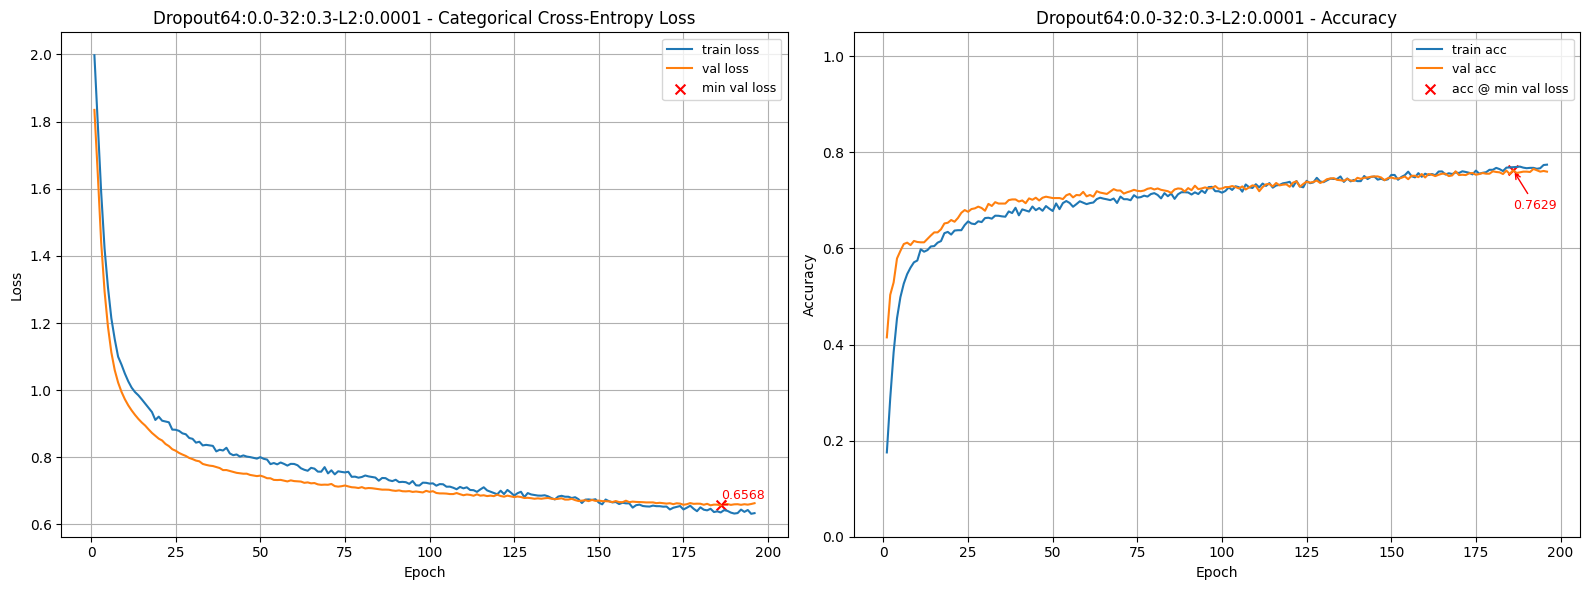

Final Training Loss:            0.6337
Final Training Accuracy:        0.7745
Final Validation Loss:          0.6633
Final Validation Accuracy:      0.7600
Minimum Validation Loss:        0.6568 (Epoch 186)
Validation Accuracy @ Min Loss: 0.7629

Test Loss: 0.6779
Test Accuracy: 0.7536

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:42

Training model with Dropout (64:0.0,32:0.3) + L2 (64:0.001,32:0.001)

Dropout64:0.0-32:0.3-L2:0.001



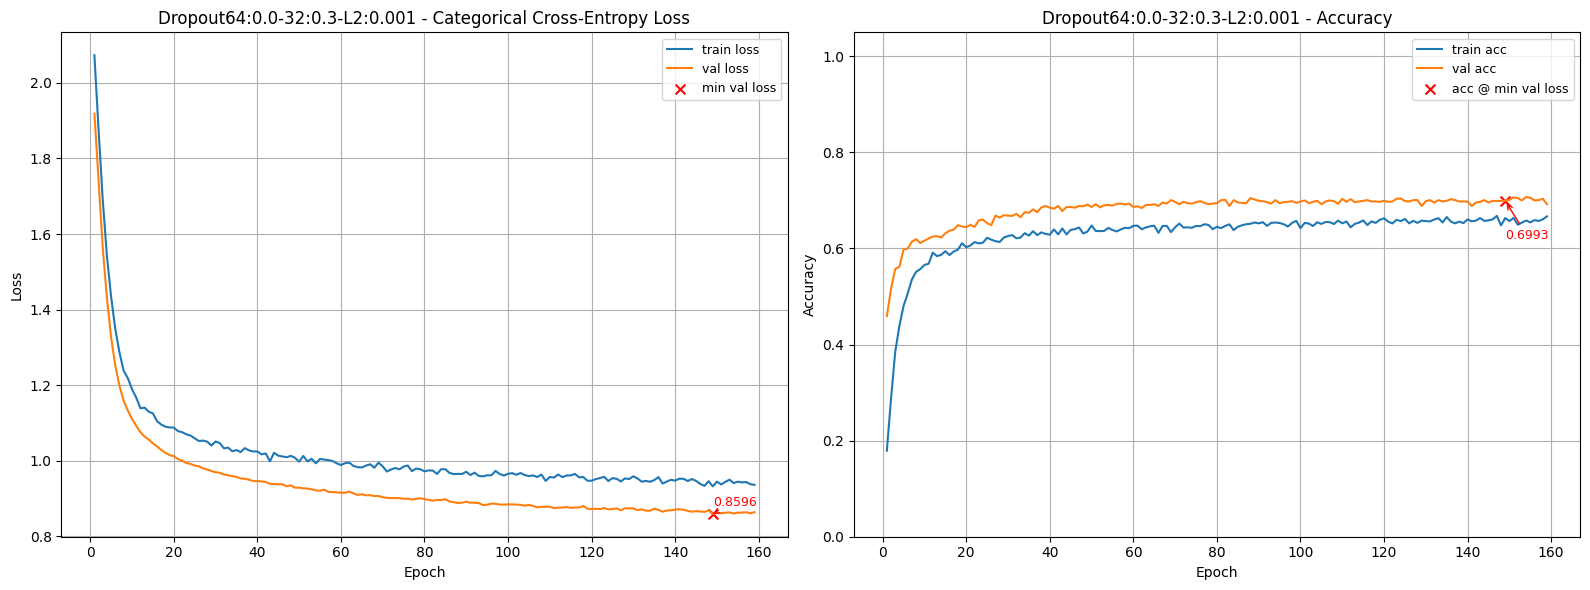

Final Training Loss:            0.9362
Final Training Accuracy:        0.6669
Final Validation Loss:          0.8639
Final Validation Accuracy:      0.6921
Minimum Validation Loss:        0.8596 (Epoch 149)
Validation Accuracy @ Min Loss: 0.6993

Test Loss: 0.8845
Test Accuracy: 0.6936

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:00:34

Training model with Dropout (64:0.0,32:0.3) + L2 (64:0.01,32:0.01)

Dropout64:0.0-32:0.3-L2:0.01



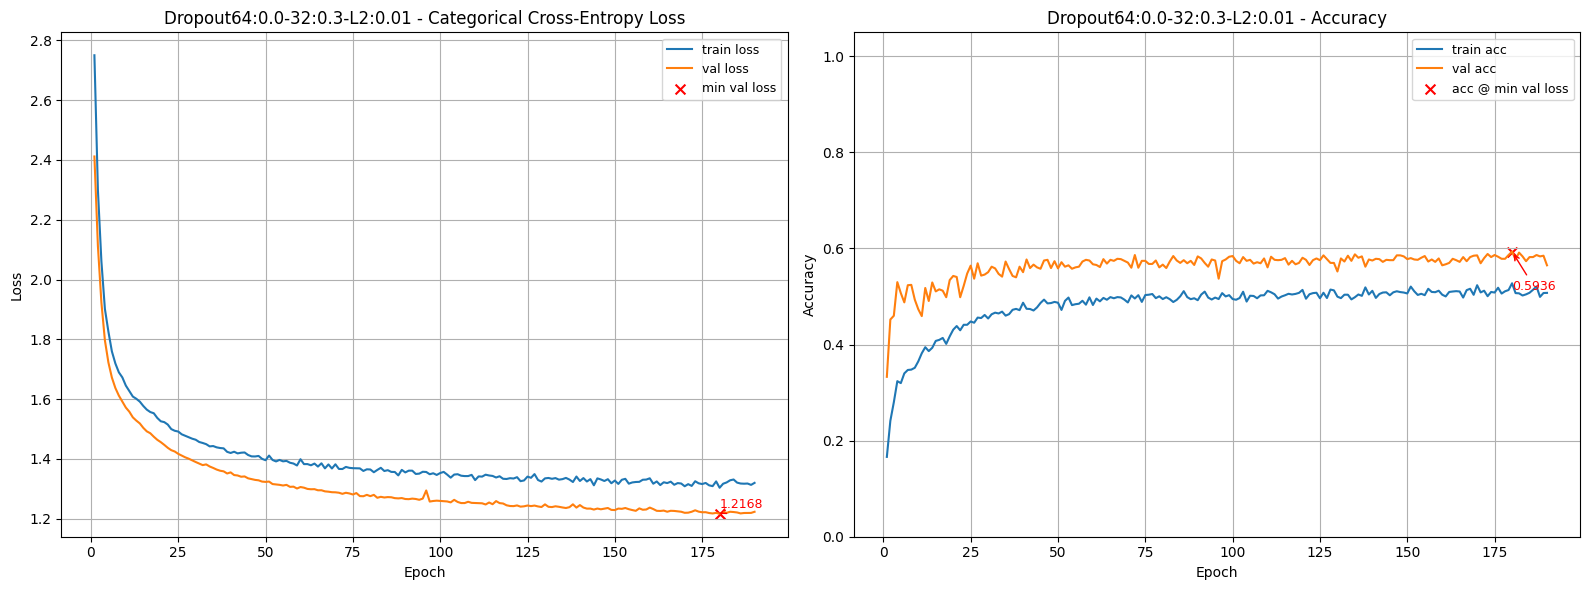

Final Training Loss:            1.3202
Final Training Accuracy:        0.5076
Final Validation Loss:          1.2236
Final Validation Accuracy:      0.5650
Minimum Validation Loss:        1.2168 (Epoch 180)
Validation Accuracy @ Min Loss: 0.5936

Test Loss: 1.2375
Test Accuracy: 0.5786

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:00:41

Training model with Dropout (64:0.0,32:0.2) + L2 (64:0.001,32:0.001)

Dropout64:0.0-32:0.2-L2:0.001



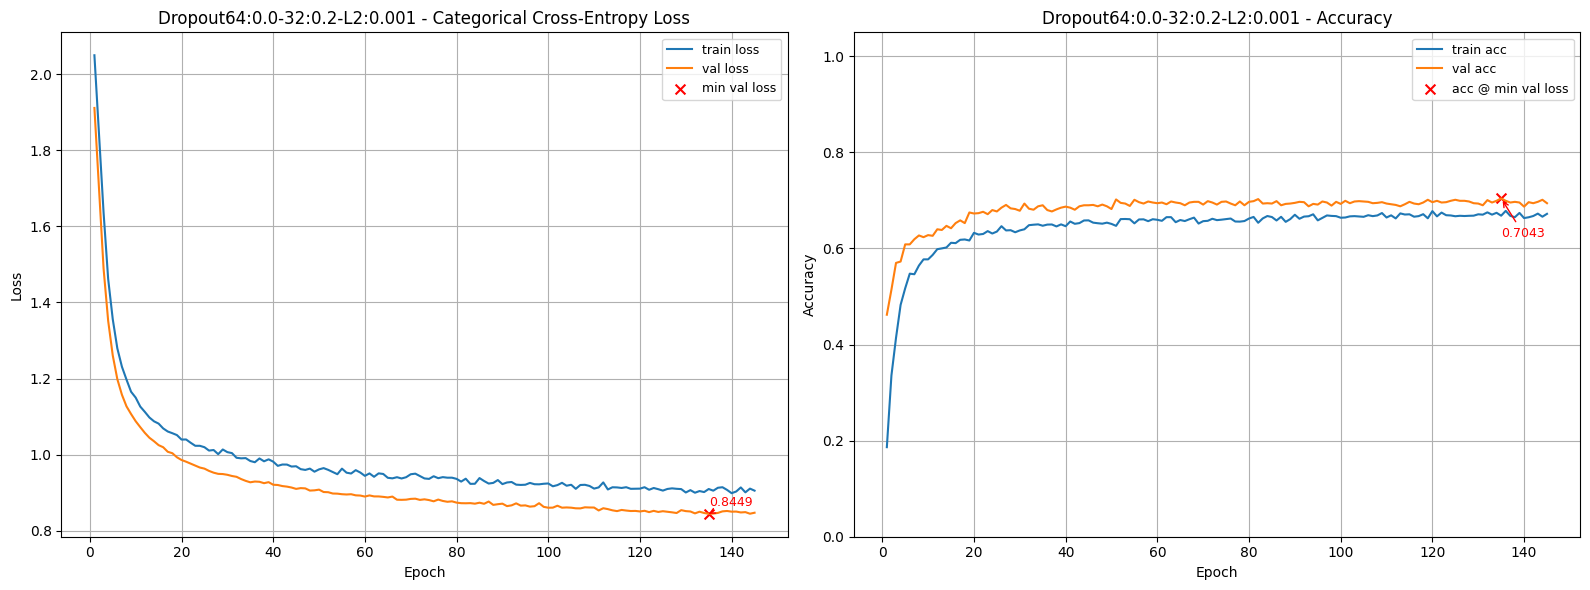

Final Training Loss:            0.9057
Final Training Accuracy:        0.6721
Final Validation Loss:          0.8477
Final Validation Accuracy:      0.6943
Minimum Validation Loss:        0.8449 (Epoch 135)
Validation Accuracy @ Min Loss: 0.7043

Test Loss: 0.8680
Test Accuracy: 0.7043

Validation-Test Gap (accuracy): 0.000000

Execution Time: 00:00:32

Best Dropout + L2 Configuration:
Dropout rates (64 units, 32 units): (0.0, 0.3)
L2 lambdas (64 units, 32 units): (0.0001, 0.0001)
Validation Accuracy: 0.7629


In [30]:
# Map activation index from Problem 1 to name
activation_name_map = {0: 'relu', 1: 'sigmoid', 2: 'tanh'}
best_activation = activation_name_map[a1a]

# Best learning rate from Problem 2
best_lr = a2a

# Starting dropout rates from Problem 3
base_dropout = a3a  # (drop64, drop32)

# L2 options to try
l2_values = [1e-4, 1e-3, 1e-2]

best_combo_acc = 0.0
best_combo = (0.0, 0.0, 0.0, 0.0)  # (drop64, drop32, l2_64, l2_32)

# 1) Keep base dropout and add L2
for l2_val in l2_values:
    d1, d2 = base_dropout
    l2_64 = l2_val
    l2_32 = l2_val
    
    print(f"\nTraining model with Dropout (64:{d1},32:{d2}) + L2 (64:{l2_64},32:{l2_32})")
    
    model_combo = build_model(
        X_train.shape[1],
        [
            (64, best_activation, l2_64, d1),
            (32, best_activation, l2_32, d2)
        ],
        n_classes
    )
    
    history = train_and_test(
        model_combo,
        lr_schedule=best_lr,
        title=f"Dropout64:{d1}-32:{d2}-L2:{l2_val}",
        verbose=0
    )
    
    val_acc = results[f"Dropout64:{d1}-32:{d2}-L2:{l2_val}"][0]
    
    if val_acc > best_combo_acc:
        best_combo_acc = val_acc
        best_combo = (d1, d2, l2_64, l2_32)

# 2) Optional: slightly reduce dropout for L2
d1_opt, d2_opt = base_dropout
d2_opt = 0.2  # slightly lower dropout
l2_val = 1e-3

print(f"\nTraining model with Dropout (64:{d1_opt},32:{d2_opt}) + L2 (64:{l2_val},32:{l2_val})")
model_combo = build_model(
    X_train.shape[1],
    [
        (64, best_activation, l2_val, d1_opt),
        (32, best_activation, l2_val, d2_opt)
    ],
    n_classes
)

history = train_and_test(
    model_combo,
    lr_schedule=best_lr,
    title=f"Dropout64:{d1_opt}-32:{d2_opt}-L2:{l2_val}",
    verbose=0
)

val_acc = results[f"Dropout64:{d1_opt}-32:{d2_opt}-L2:{l2_val}"][0]

if val_acc > best_combo_acc:
    best_combo_acc = val_acc
    best_combo = (d1_opt, d2_opt, l2_val, l2_val)

#a5a = best_combo 

print("\nBest Dropout + L2 Configuration:")
print(f"Dropout rates (64 units, 32 units): {best_combo[0], best_combo[1]}")
print(f"L2 lambdas (64 units, 32 units): {best_combo[2], best_combo[3]}")
print(f"Validation Accuracy: {best_combo_acc:.4f}")


In [31]:
# Set a5 to the validation accuracy found by this best combination of dropout and L2 regularization

a5 = best_combo_acc            # Replace 0.0 with your answer

In [32]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5 = {a5:.4f}') 

a5 = 0.7629


### Problem Six: Build and Train Your Best Model

In this final problem, you will design and train your **best-performing model** using the techniques explored in the previous problems. You may make your own choices for:

* **Model architecture** (number of layers, widths, etc.)
* **Learning rate**
* **Batch size** (a new hyperparameter not varied in earlier problems)
* **Dropout rates** in both layers
* **L2 λ values** in both layers
* **[Optional but strongly suggested]:** Learning rate scheduling, using either **Exponential Decay** or **Cosine Decay**.

  * For Exponential Decay, typical decay rates are **0.90–0.999**, with **0.95** often a good starting point.

**Steps to follow:**

* Build and train the model according to your design choices.
* Use early stopping as before to evaluate performance at the epoch of **minimum validation loss**.
* Answer the graded question.



Training Best Model with fixed learning rate...

Problem 6: Best Model (Fixed LR)

Epoch 1/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1929 - loss: 1.9678 - val_accuracy: 0.4736 - val_loss: 1.7962
Epoch 2/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3107 - loss: 1.7385 - val_accuracy: 0.5514 - val_loss: 1.5699
Epoch 3/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3876 - loss: 1.5300 - val_accuracy: 0.5779 - val_loss: 1.3821
Epoch 4/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4557 - loss: 1.3760 - val_accuracy: 0.5850 - val_loss: 1.2615
Epoch 5/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4933 - loss: 1.2831 - val_accuracy: 0.5986 - val_loss: 1.1687
Epoch 6/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5274 - loss: 1.2034 - val_accuracy: 0.5893 - val_loss: 1.0955
Epoch 7/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5493 - loss: 1.1302 - val_accuracy: 0.6014 - val_loss: 1.0406
Epoch 8/500
66/66 ━━━━━━━━━

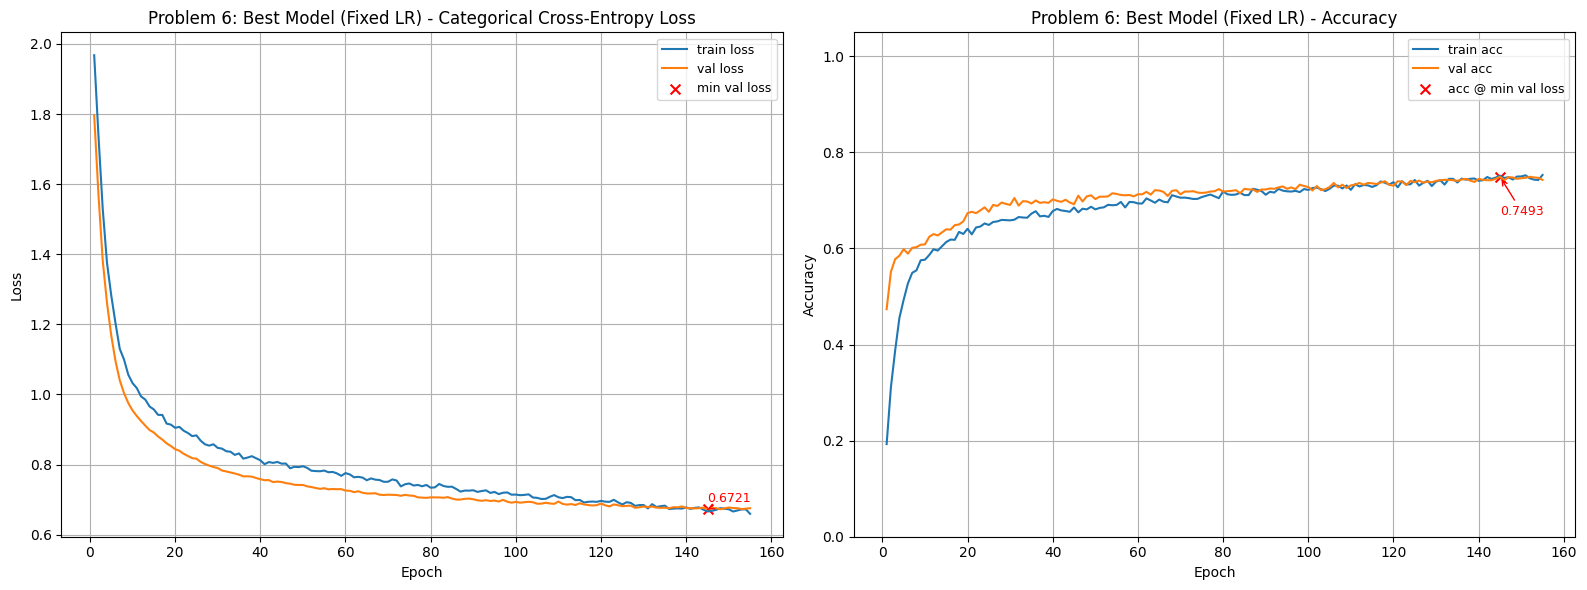

Final Training Loss:            0.6596
Final Training Accuracy:        0.7531
Final Validation Loss:          0.6755
Final Validation Accuracy:      0.7429
Minimum Validation Loss:        0.6721 (Epoch 145)
Validation Accuracy @ Min Loss: 0.7493

Test Loss: 0.6845
Test Accuracy: 0.7307

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:34

Training Best Model with Exponential Decay LR...

Problem 6: Best Model with LR Decay

Epoch 1/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1679 - loss: 1.9755 - val_accuracy: 0.4986 - val_loss: 1.8476
Epoch 2/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3169 - loss: 1.8034 - val_accuracy: 0.5736 - val_loss: 1.6669
Epoch 3/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4202 - loss: 1.5949 - val_accuracy: 0.5943 - val_loss: 1.4294
Epoch 4/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4843 - loss: 1.3946 - val_accuracy: 0.6057 - val_loss: 1.2531
Epoch 5/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/ste

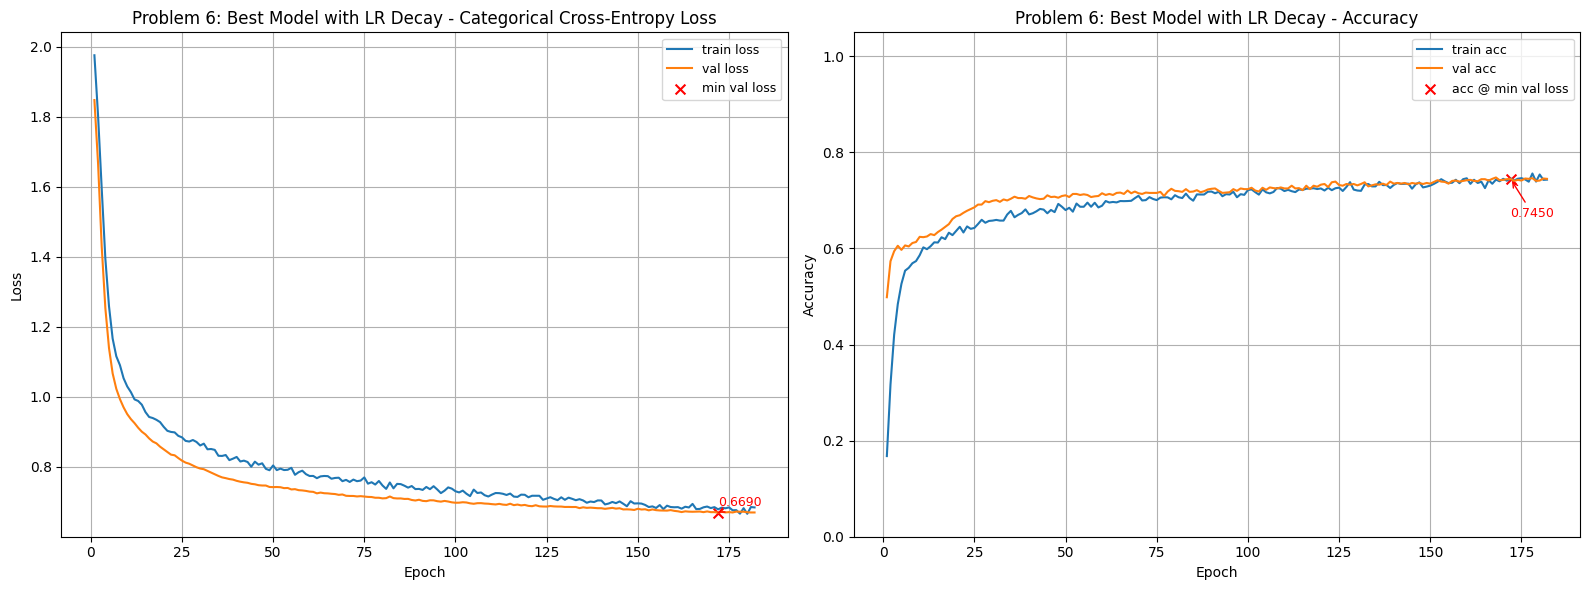

Final Training Loss:            0.6839
Final Training Accuracy:        0.7433
Final Validation Loss:          0.6695
Final Validation Accuracy:      0.7450
Minimum Validation Loss:        0.6690 (Epoch 172)
Validation Accuracy @ Min Loss: 0.7450

Test Loss: 0.6929
Test Accuracy: 0.7350

Validation-Test Gap (accuracy): 0.010000

Execution Time: 00:00:40


In [33]:
# ===============================
# Problem 6: Best Model (Correct, Dynamic)
# ===============================

 
# Map activation index from Problem 1 to name
activation_name_map = {0: 'relu', 1: 'sigmoid', 2: 'tanh'}
best_activation = activation_name_map[a1a]

# Best learning rate from Problem 2
best_lr = a2a

# Best dropout + L2 from Problem 5
drop64, drop32, l2_64, l2_32 = best_combo

# ------------------------------
# 1) Build and train with fixed learning rate
# ------------------------------
best_model_fixed = build_model(
    X_train.shape[1],
    [
        (64, best_activation, l2_64, drop64),
        (32, best_activation, l2_32, drop32)
    ],
    n_classes
)

print("\nTraining Best Model with fixed learning rate...")
train_and_test(
    best_model_fixed,
    lr_schedule=best_lr,
    title="Problem 6: Best Model (Fixed LR)",
    batch_size=64,
    verbose=1
)

# ------------------------------
# 2) Build and train with Exponential Decay learning rate
# ------------------------------
# Rebuild the model to avoid continuing training from previous run
best_model_decay = build_model(
    X_train.shape[1],
    [
        (64, best_activation, l2_64, drop64),
        (32, best_activation, l2_32, drop32)
    ],
    n_classes
)

# Exponential decay schedule
decay_rate = 0.95
decay_steps = 1000  # adjust as needed
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=best_lr,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=False
)

print("\nTraining Best Model with Exponential Decay LR...")
train_and_test(
    best_model_decay,
    lr_schedule=lr_schedule,
    title="Problem 6: Best Model with LR Decay",
    batch_size=64,
    verbose=1
)


In [34]:
# Set a6 to the validation accuracy found by this best model

a6 = results["Problem 6: Best Model (Fixed LR)"][0]        # Replace 0.0 with your answer

In [35]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a6 = {a6:.4f}') 

a6 = 0.7493


### Optional: Print out your results of all experiments

In [36]:
print_results()

Baseline - LR 0.001                     	0.7779
Baseline - Sigmoid Activation           	0.7757
Dropout 64:0.0-32:0.3                   	0.7757
Baseline - Tanh Activation              	0.7750
Baseline - ReLU Activation              	0.7729
Dropout 64:0.0-32:0.4                   	0.7714
L2 λ64:0.0001-32:0.001                  	0.7700
Baseline - LR 0.0005                    	0.7693
Dropout 64:0.0-32:0.5                   	0.7643
Dropout 64:0.2-32:0.3                   	0.7643
Dropout64:0.0-32:0.3-L2:0.0001          	0.7629
Dropout 64:0.1-32:0.5                   	0.7614
L2 λ=0.0001                             	0.7607
Dropout 64:0.1-32:0.3                   	0.7571
Dropout 64:0.1-32:0.4                   	0.7564
Dropout 64:0.2-32:0.4                   	0.7543
Problem 6: Best Model (Fixed LR)        	0.7493
Problem 6: Best Model with LR Decay     	0.7450
Dropout 64:0.2-32:0.5                   	0.7371
L2 λ=0.001                              	0.7279
Baseline - LR 0.0001                    

## Reflection Questions (ungraded)

It would be a great idea to think through your answers to these questions, then give ChatGPT (or other AI tool) a PDF of your
homework, and **discuss** (not just ask) these. 

1. Activation Functions:

    - Why do you think one activation function worked better than the others for this task?
    
    - How might this choice differ for deeper or wider networks?

2. Learning Rate:

    - Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
    
    - When is it worth training longer with a smaller step size, and when is it unnecessary?

3. Dropout vs. L2:

    - Which form of regularization — dropout or L2 — gave better results in your experiments?
    
    - Why might one method be more effective in this setting?

4. Combining Dropout and L2:

    - Why might the combination of dropout and L2 sometimes perform worse than using one method alone?
    
    - What does this tell you about the balance between bias and variance in regularization?

5. Best Model:

    - When you designed your best model, what trade-offs did you notice between model complexity, training stability, and generalization?
    
    - Did learning rate scheduling (if you tried it) improve results? Why might it help?